# Generative AI use among CU Boulder graduate respondents

This notebook cleans the survey data once, builds the main summary tables, and then
creates both detailed and presentation-ready figures. Every figure uses the same
prepared data so that rates and sample sizes stay consistent.

**A quick note about scope.** These results describe people who answered the survey.
The file does not include survey weights, full invitation records, gender, or race, so
it cannot show how closely respondents match the full graduate student population.
The tables below show where responses are complete and where sample sizes are limited.

In [234]:
# Imports and the shared Matplotlib theme.
# If needed, install the added color package once with: %pip install pypalettes
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap, to_hex

import numpy as np
import pandas as pd

from pypalettes import load_cmap, load_palette

from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)


# Shared plot styling. Individual figures choose their own palettes below.
plt.rcParams.update(
    {
        "figure.facecolor": "#F6F6F6",
        "axes.facecolor": "#F6F6F6",
        "savefig.facecolor": "#F6F6F6",
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 20,
        "axes.titleweight": "bold",
        "axes.titlelocation": "center",
        "axes.labelsize": 12,
        "axes.labelweight": "medium",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#181818",
        "axes.linewidth": 0.9,
        "axes.axisbelow": True,
        "axes.grid": True,
        "grid.color": "#A7A7A7",
        "grid.linestyle": (0, (3, 3)),
        "grid.linewidth": 0.7,
        "grid.alpha": 0.38,
        "xtick.color": "#3E3E3E",
        "ytick.color": "#3E3E3E",
        "text.color": "#3E3E3E",
        "axes.labelcolor": "#3E3E3E",
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "savefig.bbox": "tight",
    }
)


# Add a centered title and, when supplied, a smaller subtitle.
def add_title(ax, title, subtitle=None, pad=18):
    ax.set_title(title, loc="center", fontweight="bold", pad=pad)
    if subtitle:
        ax.text(
            0.5,
            1.01,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=14,
            color="#484A4C",
        )


# Place a legend below a chart.
def legend_below(ax, handles=None, labels=None, ncol=None, y=-0.25):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, y),
            ncol=ncol or len(handles),
            columnspacing=1.4,
            handlelength=1.2,
        )


# Place a legend either above or to the right of a chart.
def place_legend(
    ax,
    handles=None,
    labels=None,
    position="right",
    ncol=None,
):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()

    if not handles:
        return

    if position == "right":
        legend_settings = {
            "loc": "center left",
            "bbox_to_anchor": (1.025, 0.5),
            "ncol": 1,
        }
    elif position == "top":
        legend_settings = {
            "loc": "lower center",
            "bbox_to_anchor": (0.5, 1.03),
            "ncol": ncol or len(handles),
        }
    else:
        raise ValueError("position must be 'right' or 'top'")

    ax.legend(
        handles,
        labels,
        frameon=True,
        columnspacing=1.4,
        handlelength=1.3,
        labelspacing=1.1,
        **legend_settings,
    )



# Take evenly spaced colors from any PyPalettes palette.
def palette_colors(palette, n, start=0.12, stop=0.82, reverse=False):
    colors = load_palette(palette) if isinstance(palette, str) else palette

    if reverse:
        colors = colors[::-1]

    cmap = LinearSegmentedColormap.from_list("panel_palette", colors)

    return [
        to_hex(cmap(position))
        for position in np.linspace(start, stop, n)
    ]


# Format a pandas table and optionally shade selected numeric columns.
def style_table(frame, caption, formats=None, shade_columns=None):
    styled = (
        frame.style.hide(axis="index")
        .format(formats or {}, na_rep="—")
        .set_caption(caption)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "15px"),
                        ("font-weight", "bold"),
                        ("text-align", "left"),
                        ("color", "#3E3E3E"),
                        ("padding", "0 0 8px 0"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#3E3E3E"),
                        ("color", "white"),
                        ("text-align", "left"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("border-bottom", "1px solid #D9D9D9"),
                        ("padding", "4px 8px"),
                    ],
                },
            ]
        )
    )
    if shade_columns:
        styled = styled.background_gradient(
            cmap=load_cmap("Tangerines", cmap_type="continuous"),
            subset=shade_columns,
            axis=0,
            low=0.12,
            high=0.18,
            text_color_threshold=0.55,
        )
    return styled

In [235]:
# Survey columns and readable labels used throughout the notebook.
FREQUENCY = "GS1301_GSGAIDAY"

FREQ_ORDER = [
    "Never",
    "Several times per year",
    "Several times per month",
    "Several times per week",
    "Daily",
]
WEEKLY_LEVELS = ["Several times per week", "Daily"]


def frequency_label(value):
    return value.replace(" per ", " a ")


# Purpose question: survey column -> full label.
PURPOSE_LABELS = {
    "GS1302_GSGGAI_1": "Research a topic",
    "GS1302_GSGGAI_4": "Brainstorm ideas",
    "GS1302_GSGGAI_5": "Draft a paper or presentation",
    "GS1302_GSGGAI_6": "Revise a paper or presentation",
    "GS1302_GSGGAI_7": "Draft assignment responses",
    "GS1302_GSGGAI_8": "Revise assignment responses",
    "GS1302_GSGGAI_9": "Generate programming code",
    "GS1302_GSGGAI_10": "Revise or debug code",
    "GS1302_GSGGAI_11": "Prepare for exams",
    "GS1302_GSGGAI_12": "Translate academic/professional work",
    "GS1302_GSGGAI_999": "Other",
}

# Short purpose labels for figures with limited space.
PURPOSE_SHORT = {
    "GS1302_GSGGAI_1": "Research",
    "GS1302_GSGGAI_4": "Brainstorm",
    "GS1302_GSGGAI_5": "Draft paper",
    "GS1302_GSGGAI_6": "Revise paper",
    "GS1302_GSGGAI_7": "Draft answers",
    "GS1302_GSGGAI_8": "Revise answers",
    "GS1302_GSGGAI_9": "Generate code",
    "GS1302_GSGGAI_10": "Debug code",
    "GS1302_GSGGAI_11": "Exam prep",
    "GS1302_GSGGAI_12": "Translation",
    "GS1302_GSGGAI_999": "Other",
}

# Guidance and understanding question: survey column -> readable statement.
ATTITUDE_LABELS = {
    "GS1303_GSGAIPDC": "Professors discussed appropriate coursework use",
    "GS1303_GSGAIAUC": "I understand appropriate coursework use",
    "GS1303_GSGAIGPT": "Program guidance for teaching",
    "GS1303_GSGAIGURW": "Program guidance for research and writing",
    "GS1303_GSGAIGR": "I understand how AI generates responses",
    "GS1303_GSGAIEPDR": "I can create effective prompts",
}
LIKERT_ORDER = ["Strongly disagree", "Disagree", "Agree", "Strongly agree"]

# Short college names for tables and figures.
COLLEGE_SHORT = {
    "College of Arts & Sciences": "Arts & Sciences",
    "College of Engr & Applied Sci": "Engineering",
    "College of Media, Comm & Info": "Media, Comm & Info",
    "College of Music": "Music",
    "Cross-College Programs": "Cross-College",
    "Leeds School of Business": "Business",
    "School of Education": "Education",
}

PURPOSE_COLUMNS = list(PURPOSE_LABELS)
ATTITUDE_COLUMNS = list(ATTITUDE_LABELS)

# Demographic questions available in the supplied file.
DEMOGRAPHIC_COLUMNS = [
    "GS1204_GSDMPARENTED",  # Highest parent or guardian education
    "GS1205_GSDMSOCCLASS",  # Social class while growing up
    "GS1206_GSDMCHLDCARE",  # Cares for children
    "GS1207_GSDMADLTCARE",  # Cares for adults
]

# Basic survey and program fields used below.
INSTITUTION_COLUMNS = [
    "FINISHED",
    "PROGRESS",
    "COLLEGE_CODE1",
    "COLLEGE_NAME1",
    "PROGRAM_CODE1",
    "PROGRAM_TEXT1",
    "LEVEL_GRAD",
    "YEAR",
    "TERM1",
]

REQUIRED_COLUMNS = (
    INSTITUTION_COLUMNS
    + DEMOGRAPHIC_COLUMNS
    + [FREQUENCY]
    + PURPOSE_COLUMNS
    + ATTITUDE_COLUMNS
)

In [236]:
# Read the survey file. SERU_DATA_FILE can point to another copy when needed.
default_data_file = Path(
    "/mnt/hard_storage/GithubRepos/project-dev/Ad_Hoc/GradSurvey/"
    "CU Boulder SERU dataset_sample.xlsx"
)
data_file = Path(os.environ.get("SERU_DATA_FILE", default_data_file))
raw_survey = pd.read_excel(data_file, sheet_name="CU.BOULDER_GRAD25_Labels")

# Keep only the fields used in this notebook and add a simple row ID.
survey = raw_survey.loc[:, REQUIRED_COLUMNS].copy()
survey.insert(0, "respondent_id", np.arange(len(survey)))

# The file uses -1 for missing answers.
survey = survey.replace({-1: pd.NA, "-1": pd.NA})
survey = survey.rename(columns={"YEAR": "ENTRY_YEAR", "TERM1": "ENTRY_TERM"})

# Keep rows with one of the five listed AI-use answers.
valid_frequency = survey[FREQUENCY].isin(FREQ_ORDER)
ai_respondents = survey.loc[valid_frequency].copy()
ai_respondents["weekly_or_more"] = ai_respondents[FREQUENCY].isin(WEEKLY_LEVELS)

# Combine the five frequency options into three broad groups for later comparisons.
ai_respondents["usage_tier"] = ai_respondents[FREQUENCY].map(
    {
        "Never": "Never",
        "Several times per year": "Occasional",
        "Several times per month": "Occasional",
        "Several times per week": "Frequent",
        "Daily": "Frequent",
    }
)

# Purpose questions were shown only to people who reported using AI.
purpose_eligible = ai_respondents[FREQUENCY].ne("Never")
purpose_complete = ai_respondents[PURPOSE_COLUMNS].isin(
    ["Checked", "Not Checked"]
).all(axis=1)
purpose_base = ai_respondents.loc[purpose_eligible & purpose_complete].copy()

# Put the 11 purpose questions into one long table for plotting.
purpose_long = (
    purpose_base[
        ["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY]
        + PURPOSE_COLUMNS
    ]
    .melt(
        id_vars=["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY],
        value_vars=PURPOSE_COLUMNS,
        var_name="code",
        value_name="response",
    )
    .assign(
        Purpose=lambda frame: frame["code"].map(PURPOSE_LABELS),
        PurposeShort=lambda frame: frame["code"].map(PURPOSE_SHORT),
        Selected=lambda frame: frame["response"].eq("Checked"),
    )
)

# Put the six guidance and understanding statements into one long table.
# Each statement keeps its own number of usable answers.
attitude_long = (
    ai_respondents[
        ["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY]
        + ATTITUDE_COLUMNS
    ]
    .melt(
        id_vars=["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY],
        value_vars=ATTITUDE_COLUMNS,
        var_name="code",
        value_name="Response",
    )
)
attitude_long = attitude_long.loc[
    attitude_long["Response"].isin(LIKERT_ORDER)
].copy()
attitude_long["Item"] = attitude_long["code"].map(ATTITUDE_LABELS)

# Compare faculty discussion with students' understanding of appropriate use.
guidance_paths = ai_respondents.loc[
    ai_respondents["GS1303_GSGAIPDC"].isin(LIKERT_ORDER)
    & ai_respondents["GS1303_GSGAIAUC"].isin(LIKERT_ORDER),
    ["respondent_id", "usage_tier", "GS1303_GSGAIPDC", "GS1303_GSGAIAUC"],
].copy()
guidance_paths["Faculty discussion"] = np.where(
    guidance_paths["GS1303_GSGAIPDC"].isin(["Agree", "Strongly agree"]),
    "Discussed",
    "Not discussed",
)
guidance_paths["Appropriate-use understanding"] = np.where(
    guidance_paths["GS1303_GSGAIAUC"].isin(["Agree", "Strongly agree"]),
    "Understands",
    "Does not understand",
)

In [237]:
# Build the summary tables used by more than one figure.
frequency_summary = (
    ai_respondents[FREQUENCY]
    .value_counts()
    .reindex(FREQ_ORDER, fill_value=0)
    .rename_axis("Frequency")
    .reset_index(name="Respondents")
)
frequency_summary["Percent"] = (
    100 * frequency_summary["Respondents"] / len(ai_respondents)
)

purpose_summary = (
    purpose_long.groupby(["code", "Purpose"], observed=True)
    .agg(Selected=("Selected", "sum"), Base=("Selected", "size"))
    .reset_index()
)
purpose_summary["Percent"] = (
    100 * purpose_summary["Selected"] / purpose_summary["Base"]
)

attitude_distribution = (
    attitude_long.groupby(["code", "Item", "Response"], observed=True)
    .size()
    .rename("Respondents")
    .reset_index()
)
attitude_distribution["ItemBase"] = attitude_distribution.groupby("code")[
    "Respondents"
].transform("sum")
attitude_distribution["Percent"] = (
    100
    * attitude_distribution["Respondents"]
    / attitude_distribution["ItemBase"]
)

# Use the same four colleges in all three detailed comparison figures.
college_bases = purpose_base.groupby("COLLEGE_NAME1").size()
eligible_colleges = (
    college_bases.loc[college_bases.ge(30)]
    .sort_values(ascending=False)
    .index.tolist()
)
diagnostic_colleges = ["All colleges"] + eligible_colleges

college_purpose = (
    purpose_long.loc[purpose_long["COLLEGE_NAME1"].isin(eligible_colleges)]
    .groupby(["COLLEGE_NAME1", "code", "PurposeShort"], observed=True)
    .agg(Selected=("Selected", "sum"), Base=("Selected", "size"))
    .reset_index()
)
college_purpose["Percent"] = (
    100 * college_purpose["Selected"] / college_purpose["Base"]
)
institution_purpose = (
    purpose_long.groupby("code", observed=True)["Selected"].mean().mul(100)
)
college_purpose["Overall"] = college_purpose["code"].map(institution_purpose)
college_purpose["Delta"] = (
    college_purpose["Percent"] - college_purpose["Overall"]
)
college_purpose["College"] = college_purpose["COLLEGE_NAME1"].map(COLLEGE_SHORT)

In [238]:
# Check how many rows are available for each part of the analysis.
quality_summary = pd.DataFrame(
    [
        ("Full file", len(raw_survey), "All survey records"),
        (
            "Finished surveys",
            int(survey["FINISHED"].eq(True).sum()),
            "Shown for reference; a usable AI answer is enough for the AI analysis",
        ),
        (
            "AI-use frequency figures",
            len(ai_respondents),
            "Answered with one of the five listed frequency choices",
        ),
        (
            "Purpose figures",
            len(purpose_base),
            "Reported using AI and answered all 11 purpose questions",
        ),
        (
            "Discussion and understanding comparison",
            len(guidance_paths),
            "Answered both questions used in the comparison",
        ),
    ],
    columns=["Analysis", "Rows used", "Which rows are included"],
)

finished_ai = ai_respondents.loc[ai_respondents["FINISHED"].eq(True)]
sensitivity = pd.DataFrame(
    {
        "Group": ["All usable AI-use answers", "Finished surveys only"],
        "Respondents": [len(ai_respondents), len(finished_ai)],
        "Use AI weekly or daily": [
            ai_respondents["weekly_or_more"].mean(),
            finished_ai["weekly_or_more"].mean(),
        ],
    }
)

# Stop here if any key coding check fails.
assert ai_respondents[FREQUENCY].isin(FREQ_ORDER).all()
assert purpose_base[FREQUENCY].ne("Never").all()
assert purpose_base[PURPOSE_COLUMNS].isin(
    ["Checked", "Not Checked"]
).all().all()
assert attitude_long["Response"].isin(LIKERT_ORDER).all()
assert set(survey["LEVEL_GRAD"].dropna().astype(int).unique()) == {1, 3, 4}

display(
    style_table(
        quality_summary,
        "Rows used in each part of the analysis",
        {"Rows used": "{:,.0f}"},
        shade_columns=["Rows used"],
    )
)
display(
    style_table(
        sensitivity,
        "Check: results with and without incomplete surveys",
        {
            "Respondents": "{:,.0f}",
            "Use AI weekly or daily": "{:.1%}",
        },
        shade_columns=["Respondents", "Use AI weekly or daily"],
    )
)

Analysis,Rows used,Which rows are included
Full file,"1,387",All survey records
Finished surveys,"1,152",Shown for reference; a usable AI answer is enough for the AI analysis
AI-use frequency figures,"1,177",Answered with one of the five listed frequency choices
Purpose figures,886,Reported using AI and answered all 11 purpose questions
Discussion and understanding comparison,"1,154",Answered both questions used in the comparison


Group,Respondents,Use AI weekly or daily
All usable AI-use answers,"1,177",28.1%
Finished surveys only,"1,143",28.0%


In [239]:
# Summarize the respondent characteristics available in the file.
def summarize_category(frame, column, dimension):
    counts = (
        frame[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Respondents")
    )
    counts.insert(0, "Question", dimension)
    counts["Share"] = counts["Respondents"] / len(frame)
    return counts


overall_composition = pd.concat(
    [
        summarize_category(
            survey.assign(
                LEVEL_GRAD=survey["LEVEL_GRAD"].map(
                    lambda value: (
                        f"Code {int(value)}" if pd.notna(value) else "Missing"
                    )
                )
            ),
            "LEVEL_GRAD",
            "Degree-level code (labels not supplied)",
        ),
        summarize_category(
            survey,
            "GS1204_GSDMPARENTED",
            "Highest parent or guardian education",
        ),
        summarize_category(
            survey,
            "GS1205_GSDMSOCCLASS",
            "Social class while growing up",
        ),
        summarize_category(
            survey,
            "GS1206_GSDMCHLDCARE",
            "Cares for children",
        ),
        summarize_category(
            survey,
            "GS1207_GSDMADLTCARE",
            "Cares for adults",
        ),
    ],
    ignore_index=True,
)

display(
    style_table(
        overall_composition,
        "Respondent characteristics from the available survey fields",
        {"Respondents": "{:,.0f}", "Share": "{:.1%}"},
        shade_columns=["Respondents", "Share"],
    )
)

Question,Category,Respondents,Share
Degree-level code (labels not supplied),Code 3,"1,054",76.0%
Degree-level code (labels not supplied),Code 1,327,23.6%
Degree-level code (labels not supplied),Code 4,6,0.4%
Highest parent or guardian education,"Master’s degree (e.g., MA, MS, MBA, MSW)",352,25.4%
Highest parent or guardian education,Bachelor’s degree,295,21.3%
Highest parent or guardian education,Missing,232,16.7%
Highest parent or guardian education,"Doctoral degree (e.g., PhD, DSc, EdD)",157,11.3%
Highest parent or guardian education,High / secondary school graduate,106,7.6%
Highest parent or guardian education,"Professional degree (e.g., MD, DDS, JD, DMin, PsyD)",93,6.7%
Highest parent or guardian education,Some college,63,4.5%


In [240]:
# Compare college size and the share of rows with usable answers.
college_profile = (
    survey.groupby("COLLEGE_NAME1", observed=True)
    .agg(
        Survey_records=("respondent_id", "size"),
        Finished_share=("FINISHED", lambda values: values.eq(True).mean()),
        AI_use_answered=(
            FREQUENCY,
            lambda values: values.isin(FREQ_ORDER).mean(),
        ),
        Parent_education_answered=(
            "GS1204_GSDMPARENTED",
            lambda values: values.notna().mean(),
        ),
        Social_class_answered=(
            "GS1205_GSDMSOCCLASS",
            lambda values: values.notna().mean(),
        ),
    )
    .reset_index()
    .rename(
        columns={
            "Survey_records": "Survey records",
            "Finished_share": "Finished survey share",
            "AI_use_answered": "AI-use answer present",
            "Parent_education_answered": "Parent education answered",
            "Social_class_answered": "Social class answered",
        }
    )
)
college_profile["College"] = college_profile["COLLEGE_NAME1"].map(COLLEGE_SHORT)
college_profile = college_profile.drop(columns="COLLEGE_NAME1").sort_values(
    "Survey records", ascending=False
)

level_by_college = pd.crosstab(
    survey["COLLEGE_NAME1"].map(COLLEGE_SHORT),
    survey["LEVEL_GRAD"],
    normalize="index",
).mul(100)
level_by_college = level_by_college.reindex(
    survey["COLLEGE_NAME1"]
    .value_counts()
    .index.to_series()
    .map(COLLEGE_SHORT)
    .tolist()
).reset_index(names="College")
level_by_college = level_by_college.rename(
    columns={
        code: f"Level code {int(code)}"
        for code in level_by_college.columns[1:]
    }
)

# Create three straightforward comparisons from the available demographic fields.
parent_below_bachelors = {
    "Less than high / secondary school graduate",
    "High / secondary school graduate",
    "Some college",
    "Associate degree",
}
lower_resource_class = {"Low-income or poor", "Working-class"}
college_demographic_rows = []

for college_name, group in survey.groupby("COLLEGE_NAME1", observed=True):
    parent = group["GS1204_GSDMPARENTED"]
    parent_valid = parent.notna() & parent.ne("Unknown")
    social = group["GS1205_GSDMSOCCLASS"]
    social_valid = social.notna()
    care_columns = ["GS1206_GSDMCHLDCARE", "GS1207_GSDMADLTCARE"]
    care_valid = group[care_columns].isin(["Yes", "No"]).all(axis=1)
    any_care = group[care_columns].eq("Yes").any(axis=1)
    college_demographic_rows.append(
        {
            "College": COLLEGE_SHORT[college_name],
            "Parent education n": int(parent_valid.sum()),
            "Parent education below bachelor's": (
                parent.loc[parent_valid].isin(parent_below_bachelors).mean()
            ),
            "Social class n": int(social_valid.sum()),
            "Low-income or working-class": (
                social.loc[social_valid].isin(lower_resource_class).mean()
            ),
            "Caregiving n": int(care_valid.sum()),
            "Cares for children or adults": any_care.loc[care_valid].mean(),
        }
    )

college_demographic_profile = (
    pd.DataFrame(college_demographic_rows)
    .set_index("College")
    .reindex(college_profile["College"])
    .reset_index()
)

display(
    style_table(
        college_profile,
        "Survey coverage by college",
        {
            "Survey records": "{:,.0f}",
            "Finished survey share": "{:.1%}",
            "AI-use answer present": "{:.1%}",
            "Parent education answered": "{:.1%}",
            "Social class answered": "{:.1%}",
        },
        shade_columns=[
            "Survey records",
            "Finished survey share",
            "AI-use answer present",
            "Parent education answered",
            "Social class answered",
        ],
    )
)
display(
    style_table(
        level_by_college,
        "Degree-level codes within each college",
        {
            column: "{:.1f}%"
            for column in level_by_college.columns
            if column != "College"
        },
        shade_columns=[
            column
            for column in level_by_college.columns
            if column != "College"
        ],
    )
)
display(
    style_table(
        college_demographic_profile,
        "Selected respondent characteristics by college",
        {
            "Parent education n": "{:,.0f}",
            "Parent education below bachelor's": "{:.1%}",
            "Social class n": "{:,.0f}",
            "Low-income or working-class": "{:.1%}",
            "Caregiving n": "{:,.0f}",
            "Cares for children or adults": "{:.1%}",
        },
        shade_columns=[
            "Parent education n",
            "Parent education below bachelor's",
            "Social class n",
            "Low-income or working-class",
            "Caregiving n",
            "Cares for children or adults",
        ],
    )
)

Survey records,Finished survey share,AI-use answer present,Parent education answered,Social class answered,College
700,84.9%,87.3%,85.4%,85.4%,Arts & Sciences
476,80.9%,82.6%,80.9%,80.7%,Engineering
69,79.7%,79.7%,78.3%,78.3%,"Media, Comm & Info"
58,86.2%,87.9%,86.2%,86.2%,Education
55,76.4%,76.4%,76.4%,76.4%,Music
18,83.3%,77.8%,83.3%,83.3%,Business
11,100.0%,100.0%,100.0%,100.0%,Cross-College


College,Level code 1,Level code 3,Level code 4
Arts & Sciences,18.0%,81.1%,0.9%
Engineering,23.7%,76.3%,0.0%
"Media, Comm & Info",24.6%,75.4%,0.0%
Education,58.6%,41.4%,0.0%
Music,49.1%,50.9%,0.0%
Business,0.0%,100.0%,0.0%
Cross-College,90.9%,9.1%,0.0%


College,Parent education n,Parent education below bachelor's,Social class n,Low-income or working-class,Caregiving n,Cares for children or adults
Arts & Sciences,598,21.4%,598,29.4%,599,11.7%
Engineering,382,20.4%,384,23.7%,385,12.5%
"Media, Comm & Info",54,44.4%,54,38.9%,53,24.5%
Education,50,30.0%,50,46.0%,50,54.0%
Music,42,21.4%,42,33.3%,42,7.1%
Business,15,6.7%,15,13.3%,15,40.0%
Cross-College,11,0.0%,11,27.3%,11,0.0%


## 3. Detailed AI-question figures

Each figure starts with all colleges across the full first row. The next two rows show
the same four colleges with at least 30 complete purpose responses. Using the same
college set makes the frequency, purpose, and guidance figures easier to compare.

In [241]:
# A few small helpers keep the three five-panel figures consistent.
def college_subset(frame, college):
    if college == "All colleges":
        return frame
    return frame.loc[frame["COLLEGE_NAME1"].eq(college)]


def college_title(college):
    return "Overall" if college == "All colleges" else COLLEGE_SHORT[college]


def diagnostic_grid(figsize, height_ratios=(1, 1, 1)):
    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(
        3,
        2,
        height_ratios=height_ratios,
        hspace=0.4,
        wspace=0.18,
    )
    axes = [
        fig.add_subplot(grid[0, :]),
        fig.add_subplot(grid[1, 0]),
        fig.add_subplot(grid[1, 1]),
        fig.add_subplot(grid[2, 0]),
        fig.add_subplot(grid[2, 1]),
    ]
    return fig, axes


if len(diagnostic_colleges) != 5:
    raise ValueError("The detailed figures expect one overall panel and four colleges.")

In [242]:
# === Figure Palettes

CU_GOLDS = [
    "#F8F3E7",
    "#E8D8B5",
    "#CFB87C",
    "#A98B4F",
    "#6C562B",
]

ARTS_BLUES = [
    "#DCEAF0",
    "#ABC9D8",
    "#7CAAC1",
    "#4F789D",
    "#2C3E52",
]

ENGINEERING_REDS = [
    "#F0B7B3",
    "#DE817B",
    "#C94F48",
    "#97382A",
    "#5B2F26",
]

EDUCATION_ORANGE = [
    "#F4E8D0",
    "#EBC47B",
    "#E59500",
    "#C46F00",
    "#804A00",
]

MEDIA_GREENS = [
    "#D9E8DE",
    "#A8CDBB",
    "#6EAA8B",
    "#39775A",
    "#1E4938",
]

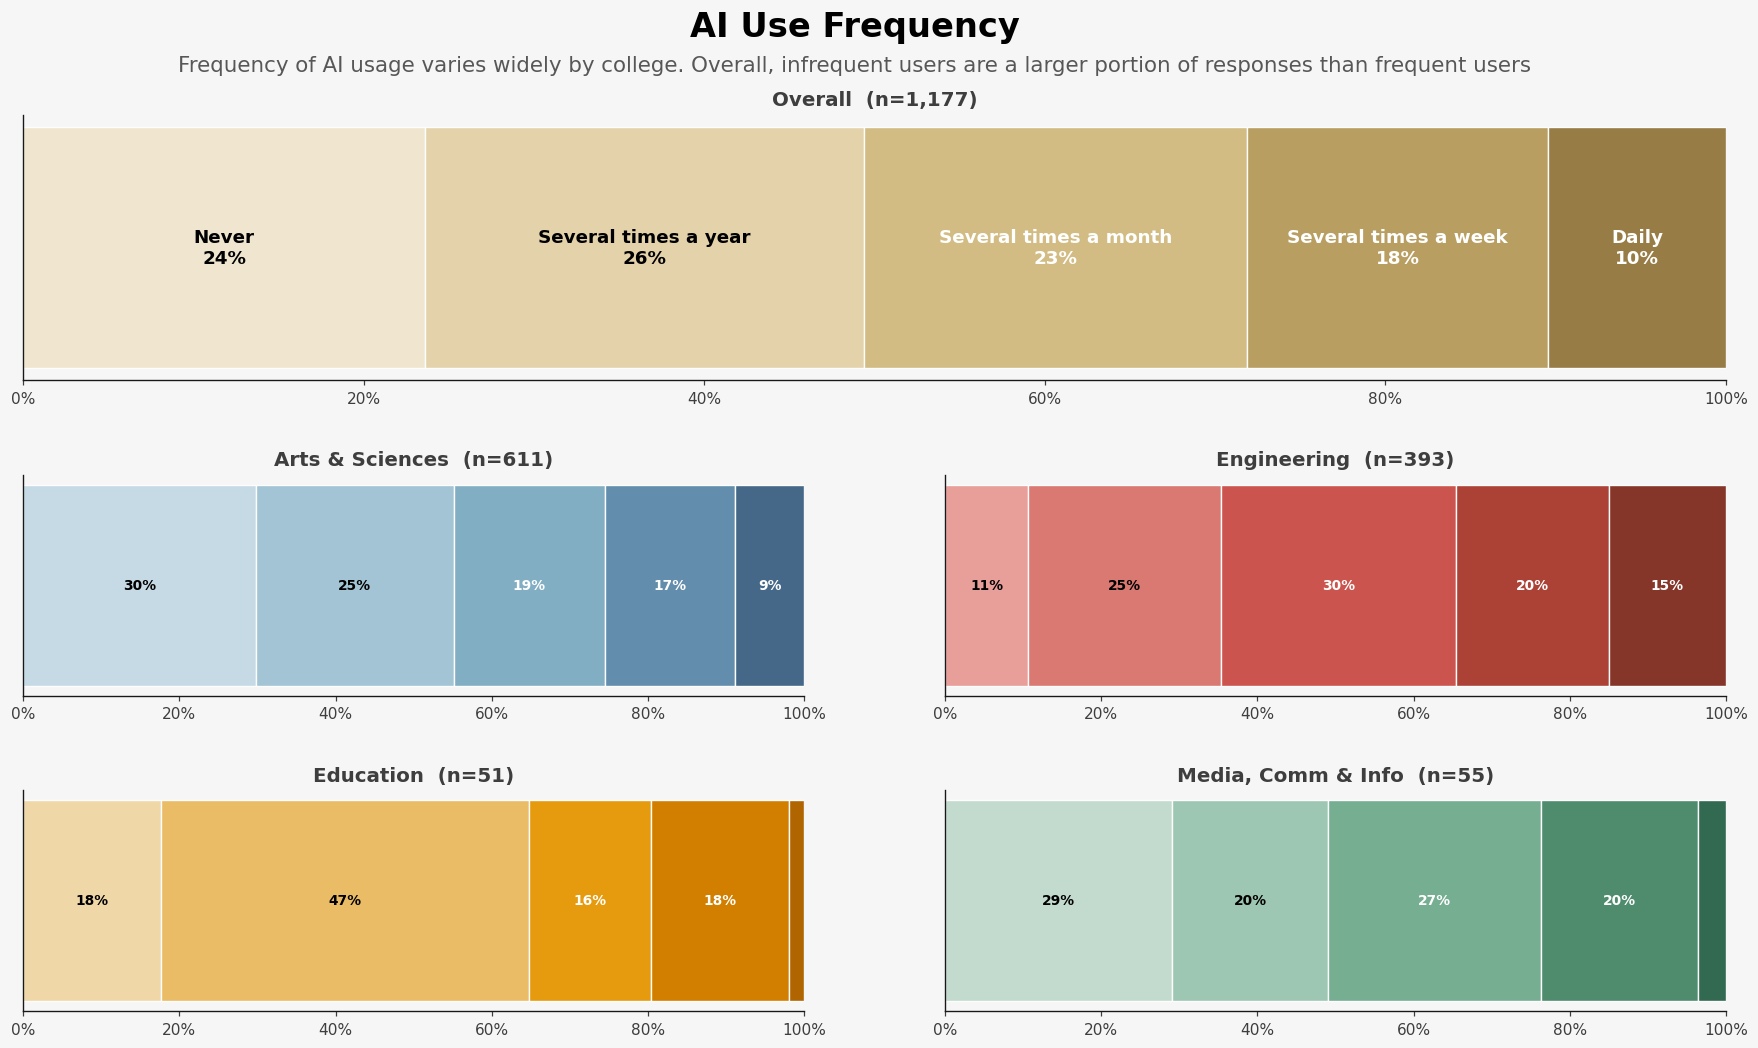

In [243]:
# AI-use frequency: overall first, followed by the four college panels.

# Custom colors


fig, axes = diagnostic_grid((18, 10), height_ratios=(1.2, 1, 1))
panel_palettes = [
    CU_GOLDS, 
    ARTS_BLUES,
    ENGINEERING_REDS,
    EDUCATION_ORANGE,
    MEDIA_GREENS
]

for panel_index, (ax, college, palette_name) in enumerate(
    zip(axes, diagnostic_colleges, panel_palettes)
):
    subset = college_subset(ai_respondents, college)
    shares = (
        subset[FREQUENCY]
        .value_counts(normalize=True)
        .reindex(FREQ_ORDER, fill_value=0)
        .mul(100)
    )
    colors = palette_colors(palette_name, len(FREQ_ORDER))
    left = 0

    for response_index, (response, color) in enumerate(
        zip(FREQ_ORDER, colors)
    ):
        width = shares[response]
        ax.barh(
            [0],
            [width],
            left=left,
            color=color,
            edgecolor="#FDFDFD",
            linewidth=0.9,
        )
        if panel_index == 0:
            label = f"{frequency_label(response)}\n{width:.0f}%"
        else:
            label = f"{width:.0f}%" if width >= 6 else ""
        if label:
            ax.text(
                left + width / 2,
                0,
                label,
                ha="center",
                va="center",
                fontsize=12 if panel_index == 0 else 9,
                fontweight="bold",
                color="white" if response_index >= 2 else "#000000",
            )
        left += width

    ax.set_xlim(0, 100)
    ax.margins(x=0)
    ax.set_yticks([])
    #ax.set_xlabel("Share of respondents")
    ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
    ax.set_title(
        f"{college_title(college)}  (n={len(subset):,})",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

fig.suptitle(
    "AI Use Frequency",
    fontsize=22,
    fontweight="bold",
    y=0.985,
).set_color("black")

fig.text(
    0.5,
    0.93,
    "Frequency of AI usage varies widely by college. Overall, infrequent users are a larger portion of responses than frequent users",
    ha="center",
    fontsize=14,
    color="#575757",
    fontweight = "medium"
)
fig.subplots_adjust(left=0.08, right=0.94, top=0.89, bottom=0.075)
plt.show()

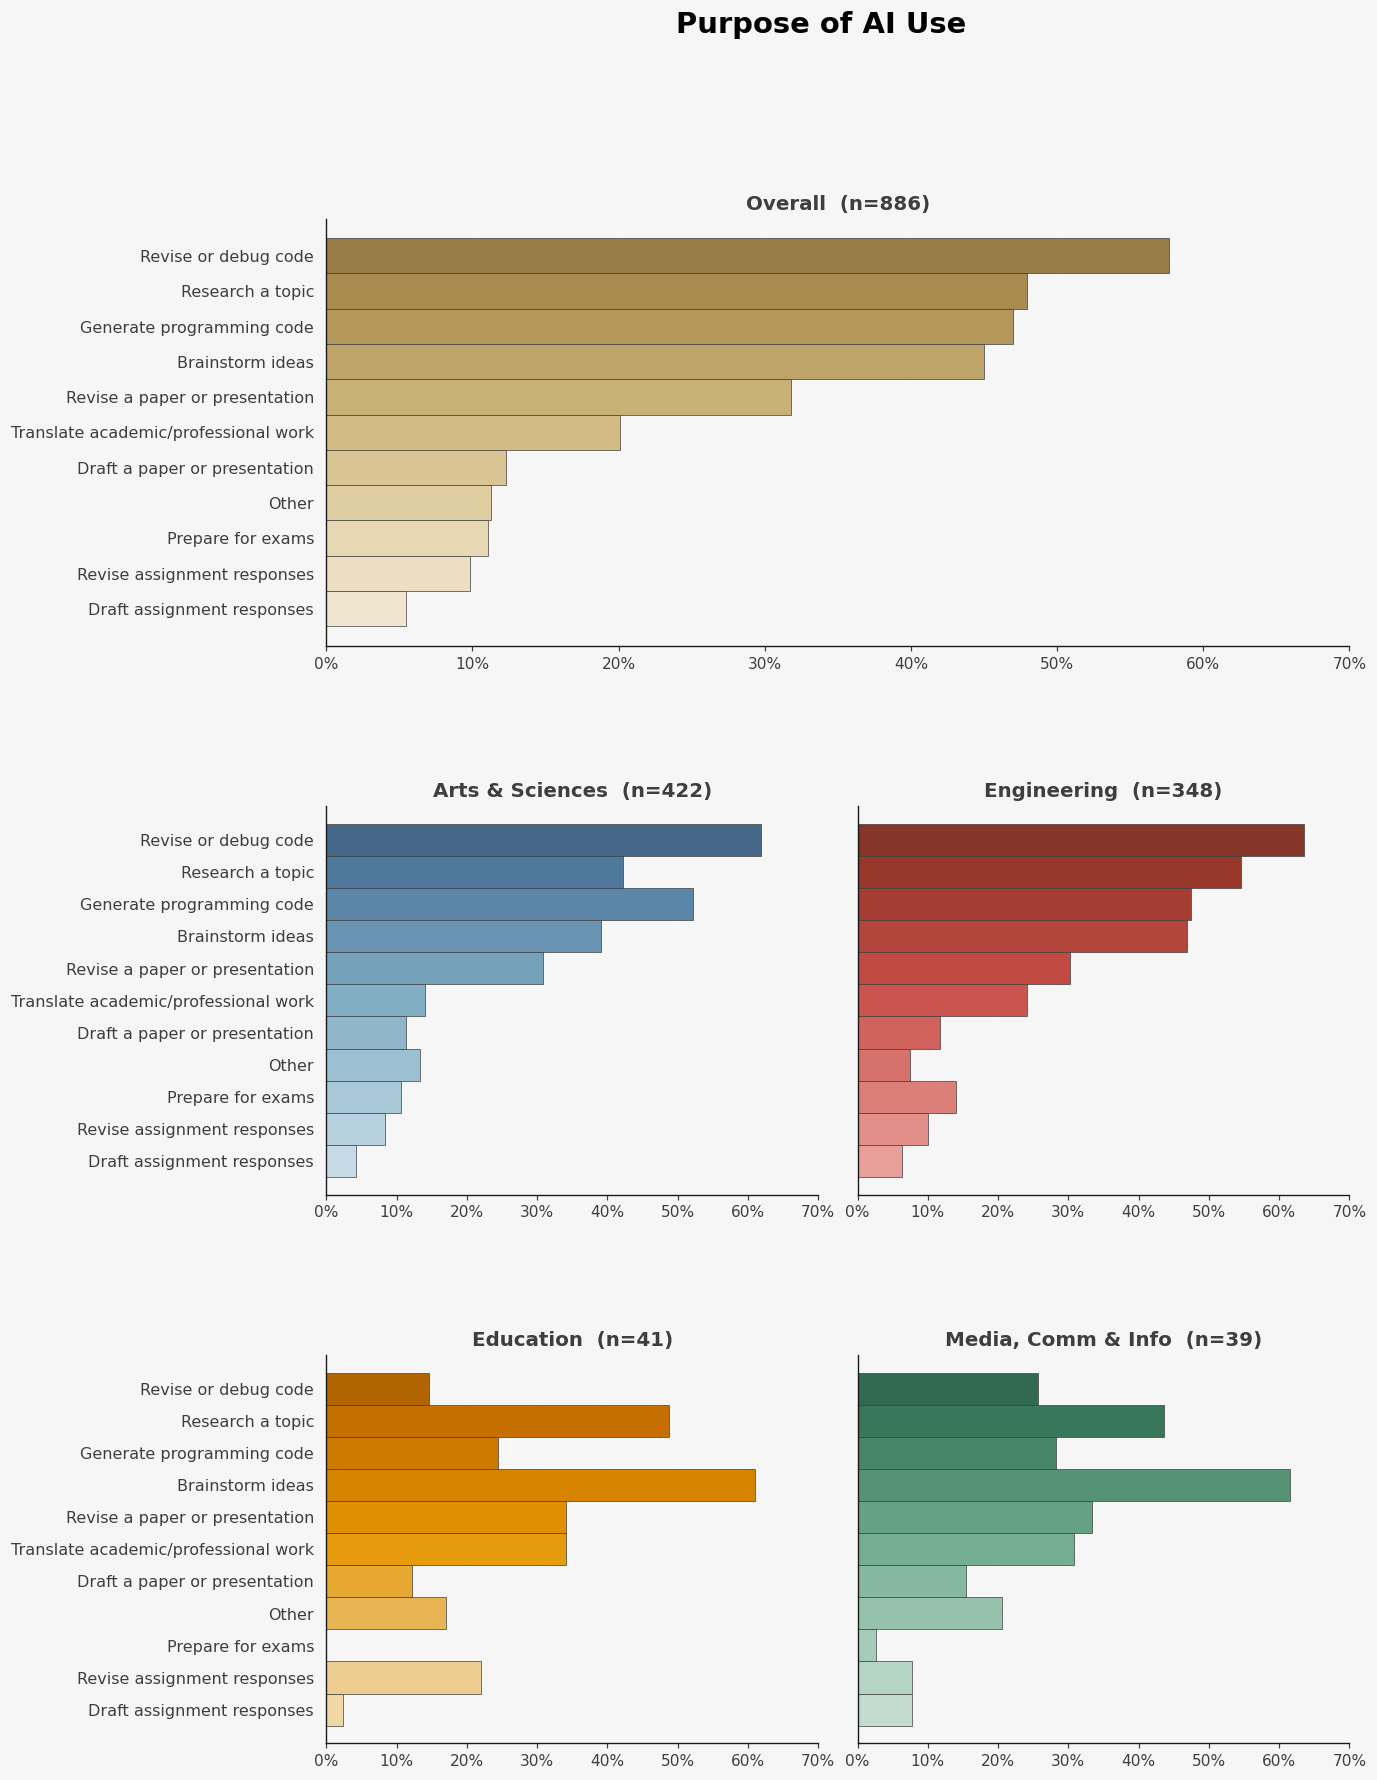

In [260]:
# Reported purposes: overall first, followed by four college panels.
fig, axes = diagnostic_grid((12, 18), height_ratios=(1.1, 1, 1))

# Tighten the two college columns for this figure only.
purpose_grid = axes[0].get_subplotspec().get_gridspec()
purpose_grid.update(wspace=0.08)

panel_palettes = [
    CU_GOLDS,
    ARTS_BLUES,
    ENGINEERING_REDS,
    EDUCATION_ORANGE,
    MEDIA_GREENS,
]

purpose_order = purpose_summary.sort_values("Percent")["code"].tolist()
purpose_labels = [PURPOSE_LABELS[code] for code in purpose_order]

for panel_index, (ax, college, palette_name) in enumerate(
    zip(axes, diagnostic_colleges, panel_palettes)
):
    subset = college_subset(purpose_long, college)

    rates = (
        subset.groupby("code", observed=True)["Selected"]
        .mean()
        .mul(100)
        .reindex(purpose_order)
    )

    respondent_n = subset["respondent_id"].nunique()
    y = np.arange(len(purpose_order))

    ax.barh(
        y,
        rates,
        height=1,
        color=palette_colors(
            palette_name,
            len(purpose_order),
        ),
        edgecolor="#3E3E3E",
        linewidth=0.45,
        zorder=2,
    )

    ax.set_xlim(0, 70)
    ax.margins(x=0)

    # Keep percentage ticks, but remove the repeated axis title.
    ax.set_xlabel("")
    ax.set_xticks(np.arange(0, 71, 10))
    ax.xaxis.set_major_formatter(
        lambda value, position: f"{value:.0f}%"
    )

    ax.set_title(
        f"{college_title(college)}  (n={respondent_n:,})",
        fontsize=13,
        fontweight="bold",
    )

    # Show full labels on the overall and left-hand panels.
    ax.set_yticks(y)

    if panel_index in {0, 1, 3}:
        ax.set_yticklabels(
            purpose_labels,
            fontsize=10.5,
            fontweight="medium",
        )
        ax.tick_params(
            axis="y",
            which="major",
            length=0,
            pad=8,
        )
    else:
        ax.set_yticklabels([])
        ax.tick_params(
            axis="y",
            which="major",
            length=0,
        )

    # Minor y ticks fall between bars, producing visible row guides.
    ax.set_yticks(
        np.arange(-0.5, len(purpose_order), 1),
        minor=True,
    )
    ax.tick_params(
        axis="y",
        which="minor",
        length=0,
    )

    # Draw the grid over the bars so that it remains visible.
    ax.set_axisbelow(True)

    ax.grid(
        axis="x",
        which="major",
        color="#FDFDFD",
        linewidth=0.5,
        linestyle="-",
        alpha=0.5,
    )

    ax.grid(
        axis="y",
        which="major",
        color="#FDFDFD",
        linewidth=0.5,
        linestyle="-",
        alpha=0.5,
    )

fig.suptitle(
    "Purpose of AI Use",
    fontsize=19,
    fontweight="bold",
    y=0.985,
).set_color("black")

# A larger left margin gives the full purpose labels more space.
# The smaller right boundary also slightly reduces the plotting area.


plt.show()

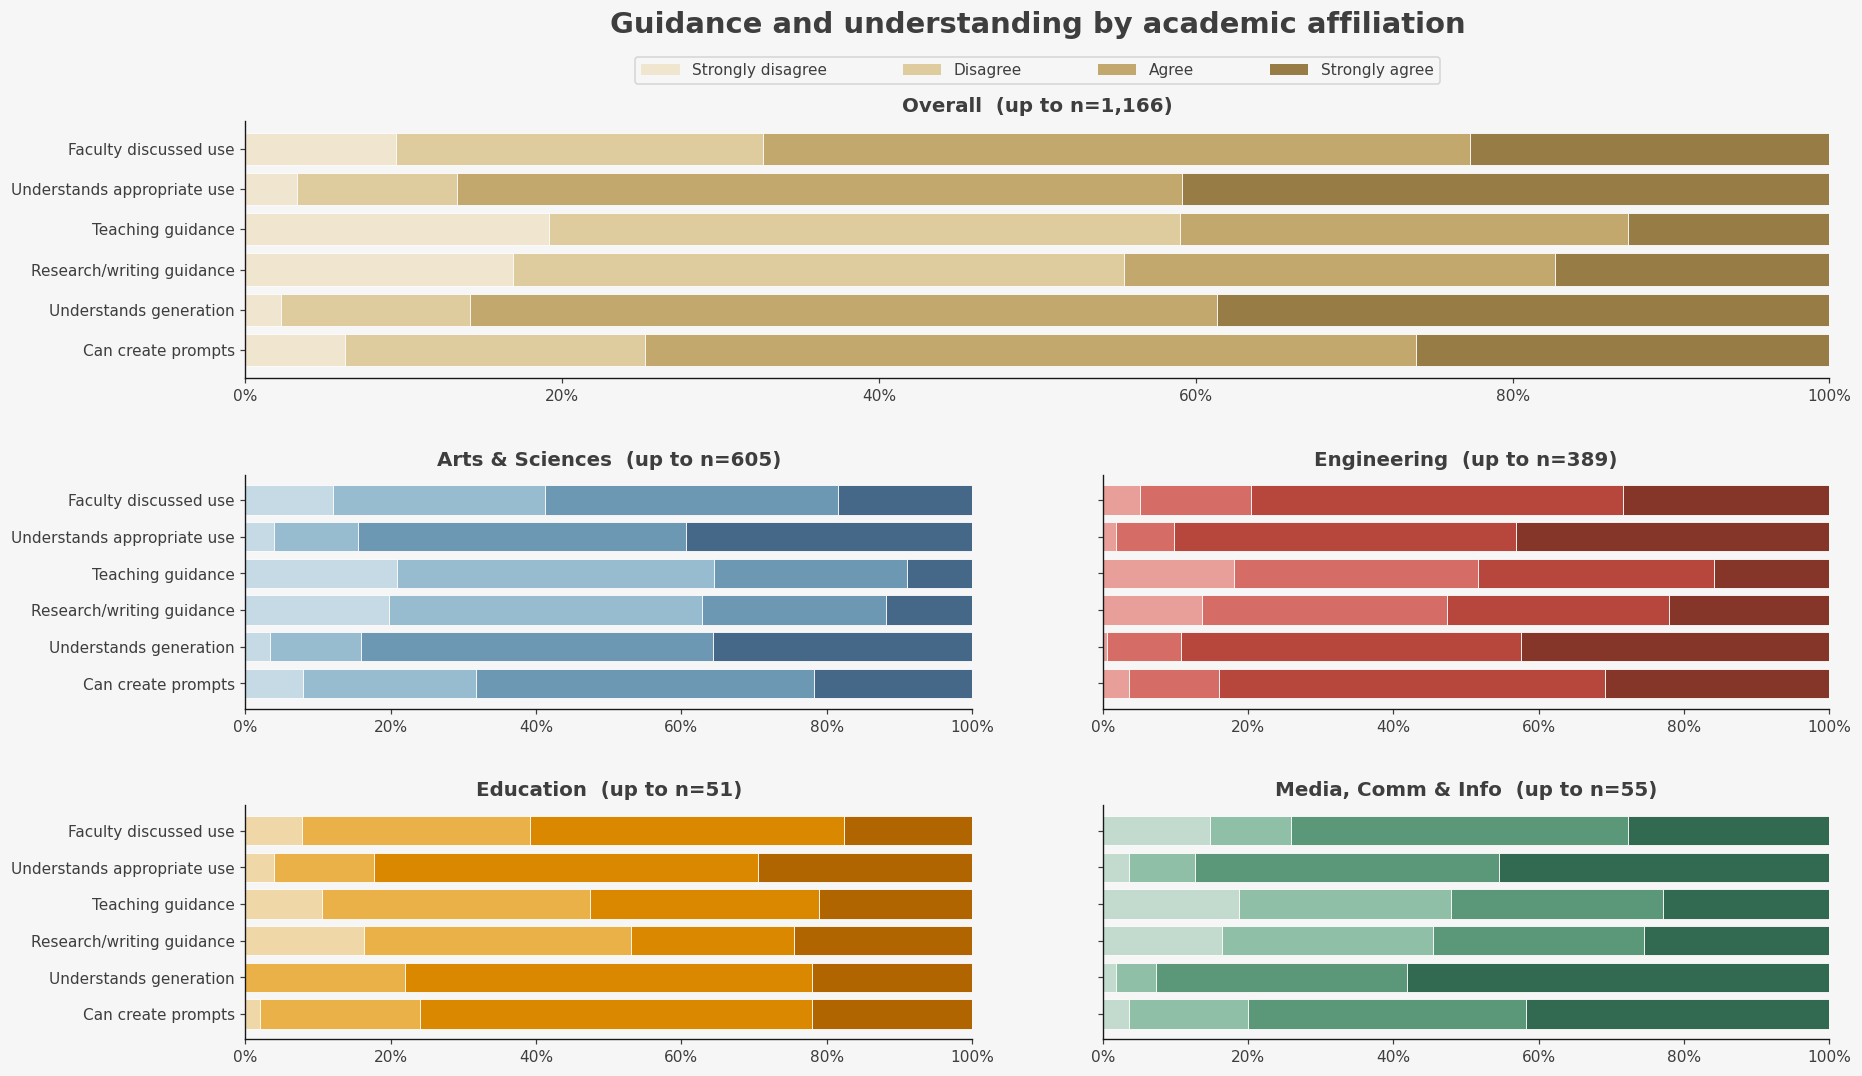

In [245]:
# Guidance and understanding: six stacked response distributions in each panel.
fig, axes = diagnostic_grid((18, 10), height_ratios=(1.1, 1, 1))
panel_palettes = [
    CU_GOLDS, 
    ARTS_BLUES,
    ENGINEERING_REDS,
    EDUCATION_ORANGE,
    MEDIA_GREENS
]

attitude_code_order = list(ATTITUDE_LABELS)

attitude_short = {
    "GS1303_GSGAIPDC": "Faculty discussed use",
    "GS1303_GSGAIAUC": "Understands appropriate use",
    "GS1303_GSGAIGPT": "Teaching guidance",
    "GS1303_GSGAIGURW": "Research/writing guidance",
    "GS1303_GSGAIGR": "Understands generation",
    "GS1303_GSGAIEPDR": "Can create prompts",
}

for panel_index, (ax, college, palette_name) in enumerate(
    zip(axes, diagnostic_colleges, panel_palettes)
):
    subset = college_subset(attitude_long, college)
    rates = (
        pd.crosstab(
            subset["code"],
            subset["Response"],
            normalize="index",
        )
        .mul(100)
        .reindex(index=attitude_code_order, columns=LIKERT_ORDER, fill_value=0)
    )
    y = np.arange(len(attitude_code_order))
    left = np.zeros(len(attitude_code_order))
    colors = palette_colors(palette_name, len(LIKERT_ORDER))

    for response, color in zip(LIKERT_ORDER, colors):
        widths = rates[response].to_numpy()
        ax.barh(
            y,
            widths,
            left=left,
            color=color,
            edgecolor="#FDFDFD",
            linewidth=0.55,
        )
        left += widths

    ax.set_xlim(0, 100)
    ax.margins(x=0)
    #ax.set_xlabel("Share of usable answers")
    ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
    respondent_n = subset["respondent_id"].nunique()
    ax.set_title(
        f"{college_title(college)}  (up to n={respondent_n:,})",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_yticks(y)
    if panel_index in {0, 1, 3}:
        ax.set_yticklabels(
            [attitude_short[code] for code in attitude_code_order]
        )
    else:
        ax.set_yticklabels([])
    ax.invert_yaxis()
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

overall_colors = palette_colors(CU_GOLDS, len(LIKERT_ORDER))
handles = [
    Rectangle((0, 0), 1, 1, facecolor=color, edgecolor="none")
    for color in overall_colors
]
fig.suptitle(
    "Guidance and understanding by academic affiliation",
    fontsize=19,
    fontweight="bold",
    y=0.99,
)
fig.legend(
    handles,
    LIKERT_ORDER,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=4,
    frameon=True,
    columnspacing=5,
    handlelength=2.5,
)
#fig.text(
#    0.5,
#    0.002,
#    "Each panel uses its own palette; the response order remains the same from left to right.",
#    ha="center",
#    fontsize=9.5,
#    color="#6F6F6F",
#)
fig.subplots_adjust(
    left=0.10,
    right=0.90,
    top=0.89,
    bottom=0.055,
)
plt.show()

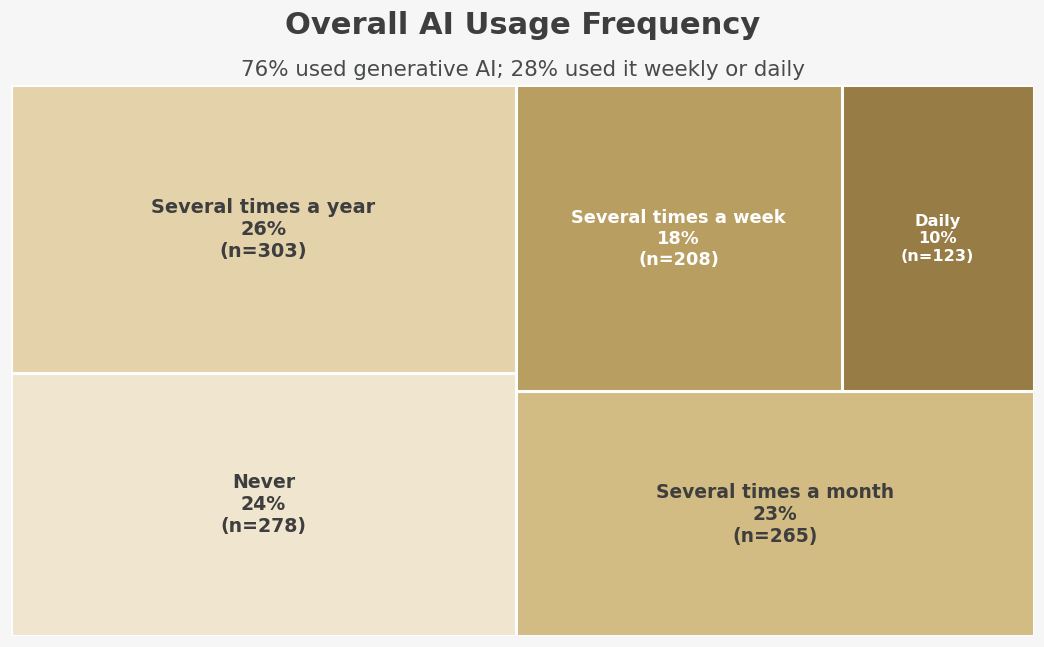

In [246]:
# Tree Plot / Prop Area

def binary_treemap(values, labels, x=0, y=0, width=100, height=60):
    values = np.asarray(values, dtype=float)
    if len(values) == 1:
        return [(x, y, width, height, labels[0], values[0])]

    cumulative = np.cumsum(values)
    split = int(np.argmin(np.abs(cumulative[:-1] - values.sum() / 2))) + 1
    first_total = values[:split].sum()
    ratio = first_total / values.sum()

    if width >= height:
        first_width = width * ratio
        return binary_treemap(
            values[:split], labels[:split], x, y, first_width, height
        ) + binary_treemap(
            values[split:],
            labels[split:],
            x + first_width,
            y,
            width - first_width,
            height,
        )

    first_height = height * ratio
    return binary_treemap(
        values[:split], labels[:split], x, y, width, first_height
    ) + binary_treemap(
        values[split:],
        labels[split:],
        x,
        y + first_height,
        width,
        height - first_height,
    )


tiles = binary_treemap(
    frequency_summary["Respondents"].to_numpy(),
    frequency_summary["Frequency"].tolist(),
)
tile_colors = palette_colors(CU_GOLDS, len(FREQ_ORDER))
ever_used = 100 * ai_respondents[FREQUENCY].ne("Never").mean()
weekly_used = 100 * ai_respondents["weekly_or_more"].mean()

fig, ax = plt.subplots(figsize=(12, 6.5))
for tile_index, ((x, y, width, height, label, count), color) in enumerate(
    zip(tiles, tile_colors)
):
    percent = 100 * count / len(ai_respondents)
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            facecolor=color,
            edgecolor="#FDFDFD",
            linewidth=2,
        )
    )
    ax.text(
        x + width / 2,
        y + height / 2,
        f"{frequency_label(label)}\n{percent:.0f}%\n(n={int(count):,})",
        ha="center",
        va="center",
        color="white" if tile_index >= 3 else "#3E3E3E",
        fontweight="bold",
        fontsize=max(9, min(15, 7 + np.sqrt(width * height) / 7)),
    )

ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.margins(0)
#ax.set_aspect("equal")
ax.axis("off")

add_title(
    ax,
    "Overall AI Usage Frequency",
    f"{ever_used:.0f}% used generative AI; {weekly_used:.0f}% used it weekly or daily",
    pad=34,
)
#plt.tight_layout()
plt.show()

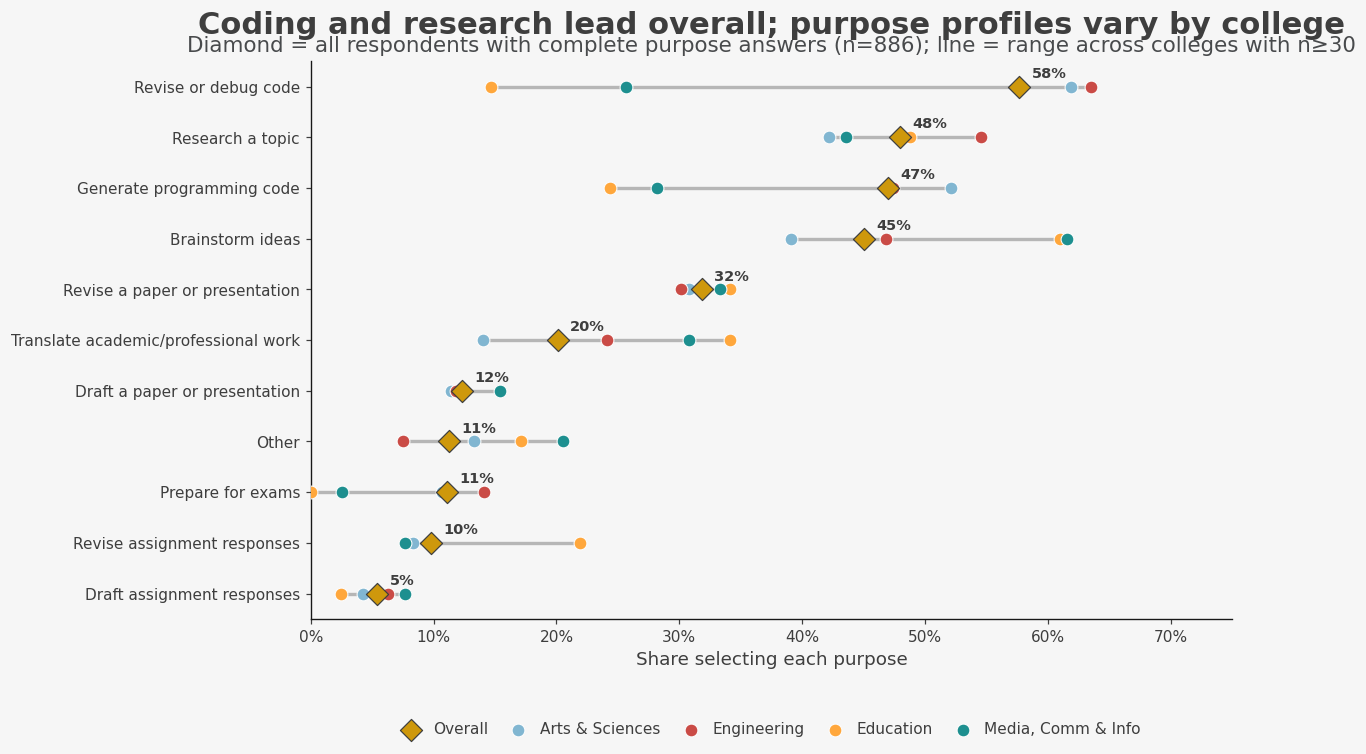

In [247]:
# Compare each overall purpose rate with the four college rates.
purpose_order = purpose_summary.sort_values("Percent")["code"].tolist()
overall_rates = institution_purpose.reindex(purpose_order)
college_rate_matrix = (
    college_purpose.pivot(
        index="code",
        columns="COLLEGE_NAME1",
        values="Percent",
    )
    .reindex(index=purpose_order, columns=eligible_colleges)
)
y = np.arange(len(purpose_order))

college_palette_names = ["andorian", "Epinephelus_striatus", "Tangerines", "Teals"]
college_colors = [
    palette_colors(name, 5)[3] for name in college_palette_names
]
overall_color = palette_colors("Gold", 5)[2]

fig, ax = plt.subplots(figsize=(12.5, 7.8))
ax.hlines(
    y,
    college_rate_matrix.min(axis=1),
    college_rate_matrix.max(axis=1),
    color="#A7A7A7",
    linewidth=2.2,
    alpha=0.8,
    zorder=1,
)

for college, color in zip(eligible_colleges, college_colors):
    ax.scatter(
        college_rate_matrix[college],
        y,
        s=70,
        color=color,
        edgecolor="#FDFDFD",
        linewidth=0.7,
        label=COLLEGE_SHORT[college],
        zorder=3,
    )

ax.scatter(
    overall_rates,
    y,
    s=105,
    marker="D",
    color=overall_color,
    edgecolor="#3E3E3E",
    linewidth=0.8,
    label="Overall",
    zorder=4,
)
for y_value, percent in zip(y, overall_rates):
    ax.text(
        percent + 1.0,
        y_value + 0.12,
        f"{percent:.0f}%",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
    )

ax.set_yticks(y)
ax.set_yticklabels([PURPOSE_LABELS[code] for code in purpose_order])
ax.set_xlim(0, 75)
ax.margins(x=0)
ax.set_xlabel("Share selecting each purpose")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)

handles, labels = ax.get_legend_handles_labels()
overall_position = labels.index("Overall")
handles = [handles[overall_position]] + handles[:overall_position]
labels = [labels[overall_position]] + labels[:overall_position]
legend_below(ax, handles, labels, ncol=5, y=-0.16)
add_title(
    ax,
    "Coding and research lead overall; purpose profiles vary by college",
    (
        f"Diamond = all respondents with complete purpose answers (n={len(purpose_base):,}); "
        "line = range across colleges with n≥30"
    ),
)
plt.subplots_adjust(left=0.30, bottom=0.19, top=0.84, right=0.97)
plt.show()

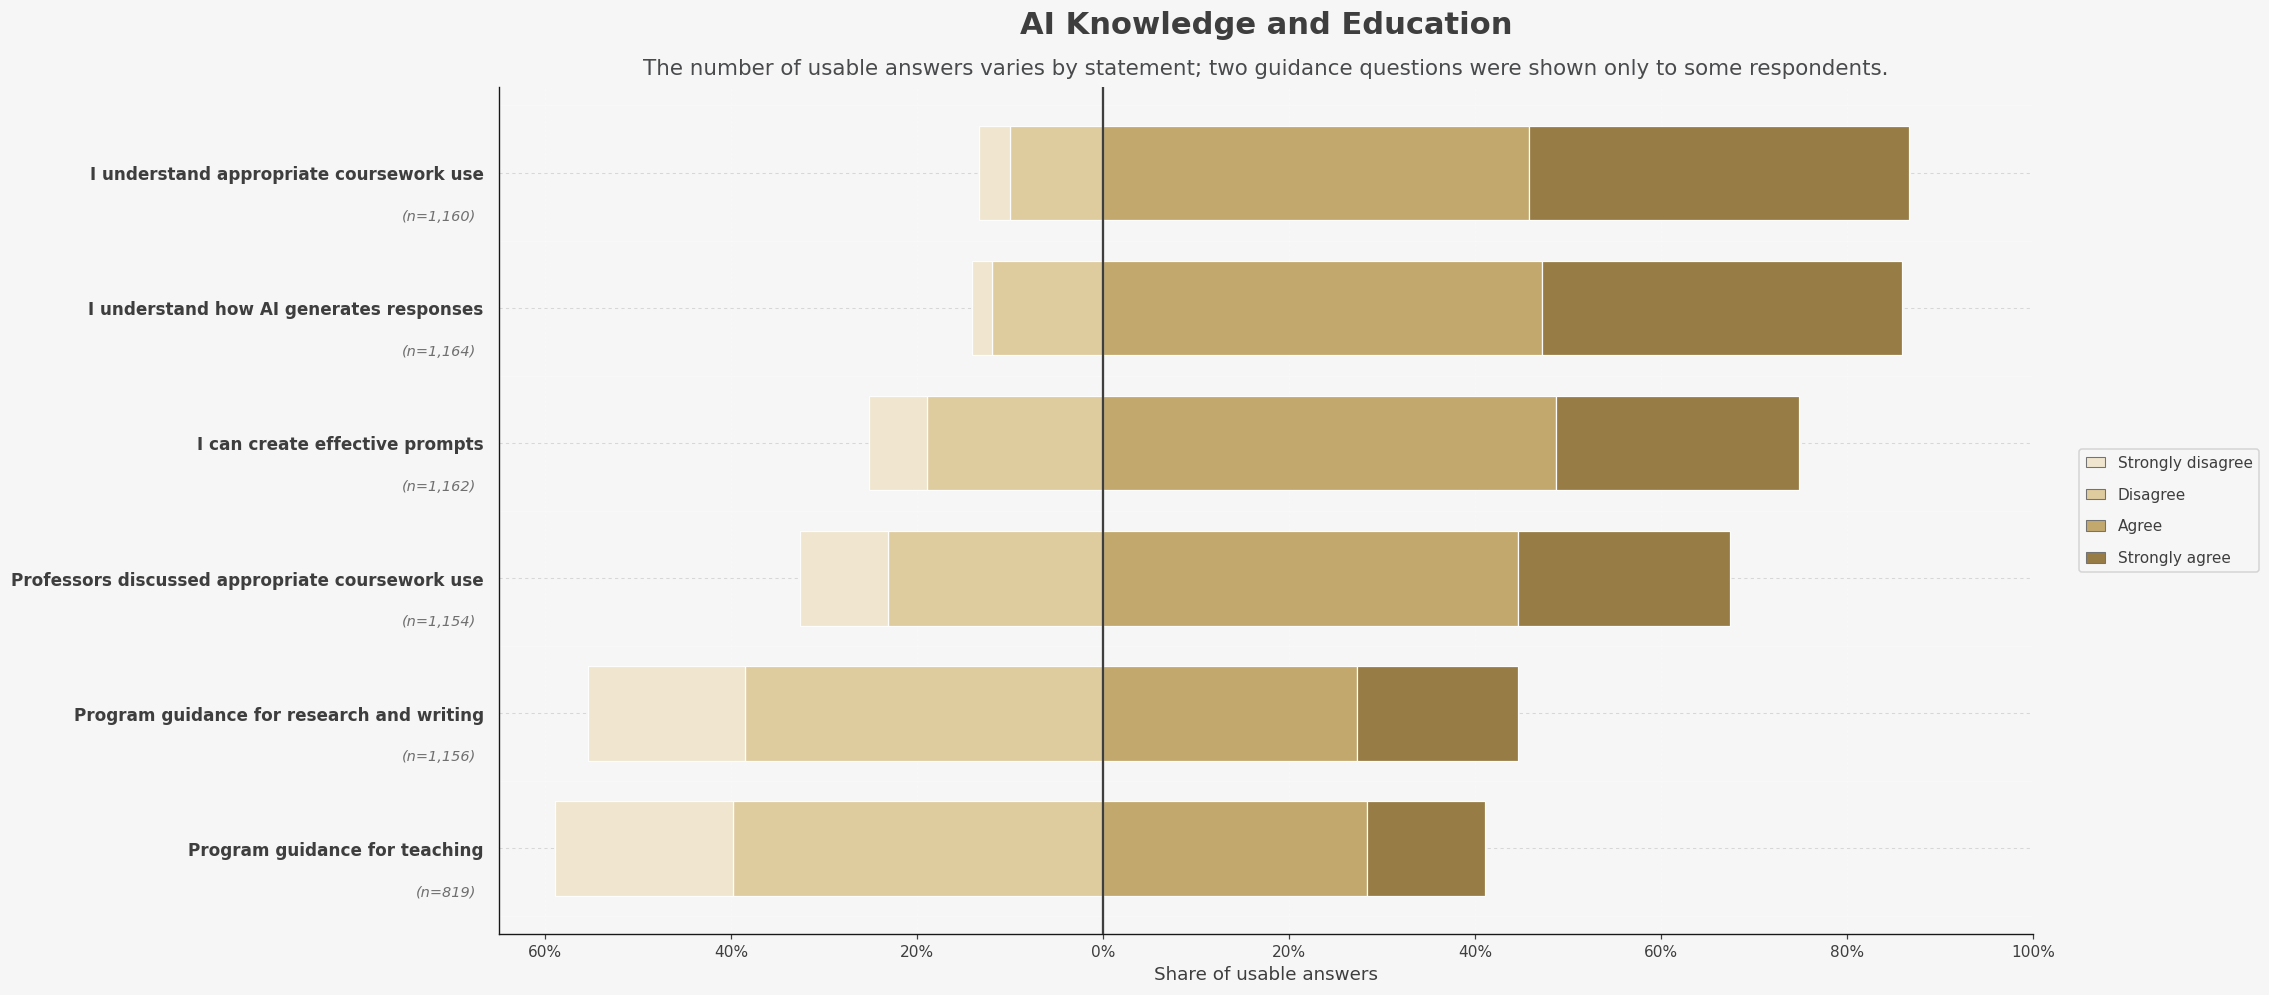

In [248]:


# Put disagreement to the left of zero and agreement to the right.
attitude_topbox = (
    attitude_long.assign(
        Agree=lambda frame: frame["Response"].isin(
            ["Agree", "Strongly agree"]
        )
    )
    .groupby(["code", "Item"], observed=True)["Agree"]
    .agg(["mean", "size"])
    .reset_index()
    .rename(columns={"mean": "TopBox", "size": "ItemBase"})
    .sort_values("TopBox")
)

item_order = attitude_topbox["code"].tolist()
y = np.arange(len(item_order))

# Use the current CU palette rather than the old PyPalettes Gold scale.
likert_colors = palette_colors(
    CU_GOLDS,
    len(LIKERT_ORDER),
)

# Match the 18-by-10 canvas used by the other figures.
fig, ax = plt.subplots(figsize=(18, 10))

negative_left = np.zeros(len(item_order))
positive_left = np.zeros(len(item_order))

# Disagree sits next to zero; strongly disagree is farther left.
for response, color in zip(
    ["Disagree", "Strongly disagree"],
    [likert_colors[1], likert_colors[0]],
):
    widths = (
        attitude_distribution.loc[
            attitude_distribution["Response"].eq(response)
        ]
        .set_index("code")["Percent"]
        .reindex(item_order, fill_value=0)
        .to_numpy()
    )

    ax.barh(
        y,
        -widths,
        left=negative_left,
        color=color,
        edgecolor="#FDFDFD",
        linewidth=0.8,
        height=0.70,
        zorder=2,
    )

    negative_left -= widths

# Agree sits next to zero; strongly agree is farther right.
for response, color in zip(
    ["Agree", "Strongly agree"],
    [likert_colors[2], likert_colors[3]],
):
    widths = (
        attitude_distribution.loc[
            attitude_distribution["Response"].eq(response)
        ]
        .set_index("code")["Percent"]
        .reindex(item_order, fill_value=0)
        .to_numpy()
    )

    ax.barh(
        y,
        widths,
        left=positive_left,
        color=color,
        edgecolor="#FDFDFD",
        linewidth=0.8,
        height=0.70,
        zorder=2,
    )

    positive_left += widths

# Statement labels
ax.set_yticks(y)
ax.set_yticklabels(
    [ATTITUDE_LABELS[code] for code in item_order],
    fontsize=11,
    fontweight="semibold",
)
ax.tick_params(
    axis="y",
    which="major",
    length=0,
    pad=10,
)

# Put minor ticks between statements for horizontal gridlines.
ax.set_yticks(
    np.arange(-0.5, len(item_order), 1),
    minor=True,
)
ax.tick_params(
    axis="y",
    which="minor",
    length=0,
)

# Show the number of usable answers below each statement.
for y_value, item_code in zip(y, item_order):
    item_n = int(
        attitude_topbox.loc[
            attitude_topbox["code"].eq(item_code),
            "ItemBase",
        ].iloc[0]
    )

    ax.text(
        -0.015,
        y_value - 0.27,
        f"(n={item_n:,})",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="top",
        fontsize=9.5,
        fontstyle="italic",
        color="#6F6F6F",
    )

# Axes
ax.set_xlim(-65, 100)
ax.margins(x=0)
ax.set_xlabel("Share of usable answers")
ax.set_xticks(np.arange(-60, 101, 20))
ax.xaxis.set_major_formatter(
    lambda value, position: f"{abs(value):.0f}%"
)

# Draw visible gridlines over the filled bars.
ax.set_axisbelow(True)

ax.grid(
    axis="x",
    which="major",
    color="#FDFDFD",
    linewidth=0.5,
    linestyle=(0, (3, 3)),
    alpha=0.50,
)

ax.grid(
    axis="y",
    which="minor",
    color="#FDFDFD",
    linewidth=0.5,
    linestyle="-",
    alpha=0.50,
)

# Redraw the center line over the grid.
ax.axvline(
    0,
    color="#3E3E3E",
    linewidth=1.5,
    zorder=5,
)

# Right-side legend
handles = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor=color,
        edgecolor="#737373",
        linewidth=0.7,
    )
    for color in likert_colors
]

place_legend(
    ax,
    handles,
    LIKERT_ORDER,
    position="right",
)

add_title(
    ax,
    "AI Knowledge and Education",
    (
        "The number of usable answers varies by statement; "
        "two guidance questions were shown only to some respondents."
    ),
    pad=35,
)


plt.show()

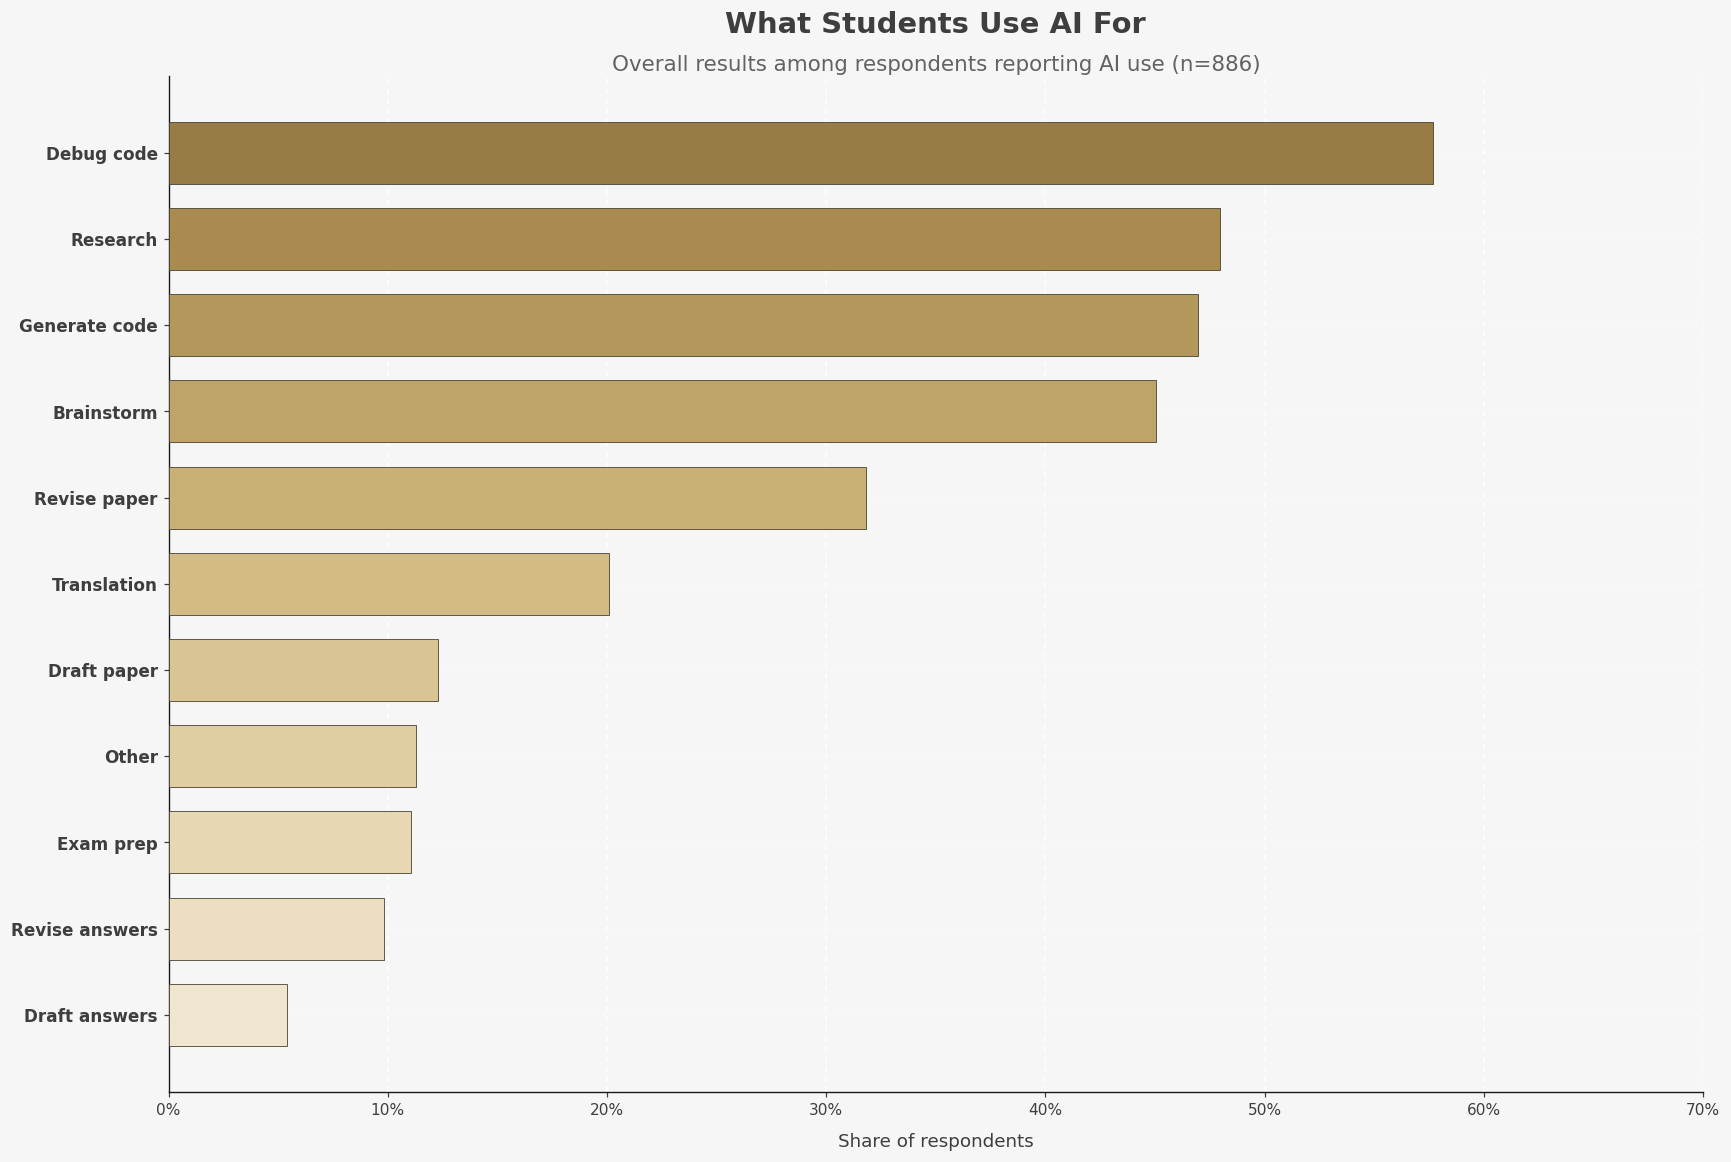

In [268]:
# Show the overall percentage of students reporting each AI use.
purpose_order = (
    purpose_summary
    .sort_values("Percent")
    ["code"]
    .tolist()
)

overall_purpose_rates = (
    purpose_summary
    .set_index("code")
    ["Percent"]
    .reindex(purpose_order)
)

overall_purpose_n = (
    purpose_long["respondent_id"]
    .nunique()
)

purpose_labels = [
    PURPOSE_SHORT[code]
    for code in purpose_order
]

y = np.arange(len(purpose_order))

fig, ax = plt.subplots(figsize=(18, 12))

ax.barh(
    y,
    overall_purpose_rates.to_numpy(),
    color=palette_colors(
        CU_GOLDS,
        len(purpose_order),
    ),
    edgecolor="#4A4334",
    linewidth=0.55,
    height=0.72,
    zorder=3,
)

ax.set_yticks(y)
ax.set_yticklabels(
    purpose_labels,
    fontsize=11,
    fontweight="semibold",
)

ax.set_xlim(0, 70)
ax.margins(x=0)

ax.set_xlabel(
    "Share of respondents",
    fontsize=12,
    labelpad=10,
)
ax.xaxis.set_major_formatter(
    lambda value, position: f"{value:.0f}%"
)

ax.set_title(
    "What Students Use AI For",
    fontsize=19,
    fontweight="bold",
    pad=28,
)

ax.text(
    0.5,
    1.02,
    f"Overall results among respondents reporting AI use (n={overall_purpose_n:,})",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=14,
    color="#626262",
)

ax.set_axisbelow(True)
ax.grid(
    axis="x",
    color="#FFFFFF",
    linewidth=1.1,
    alpha=0.9,
)
ax.grid(
    axis="y",
    color="#FFFFFF",
    linewidth=0.8,
    alpha=0.55,
)


plt.show()

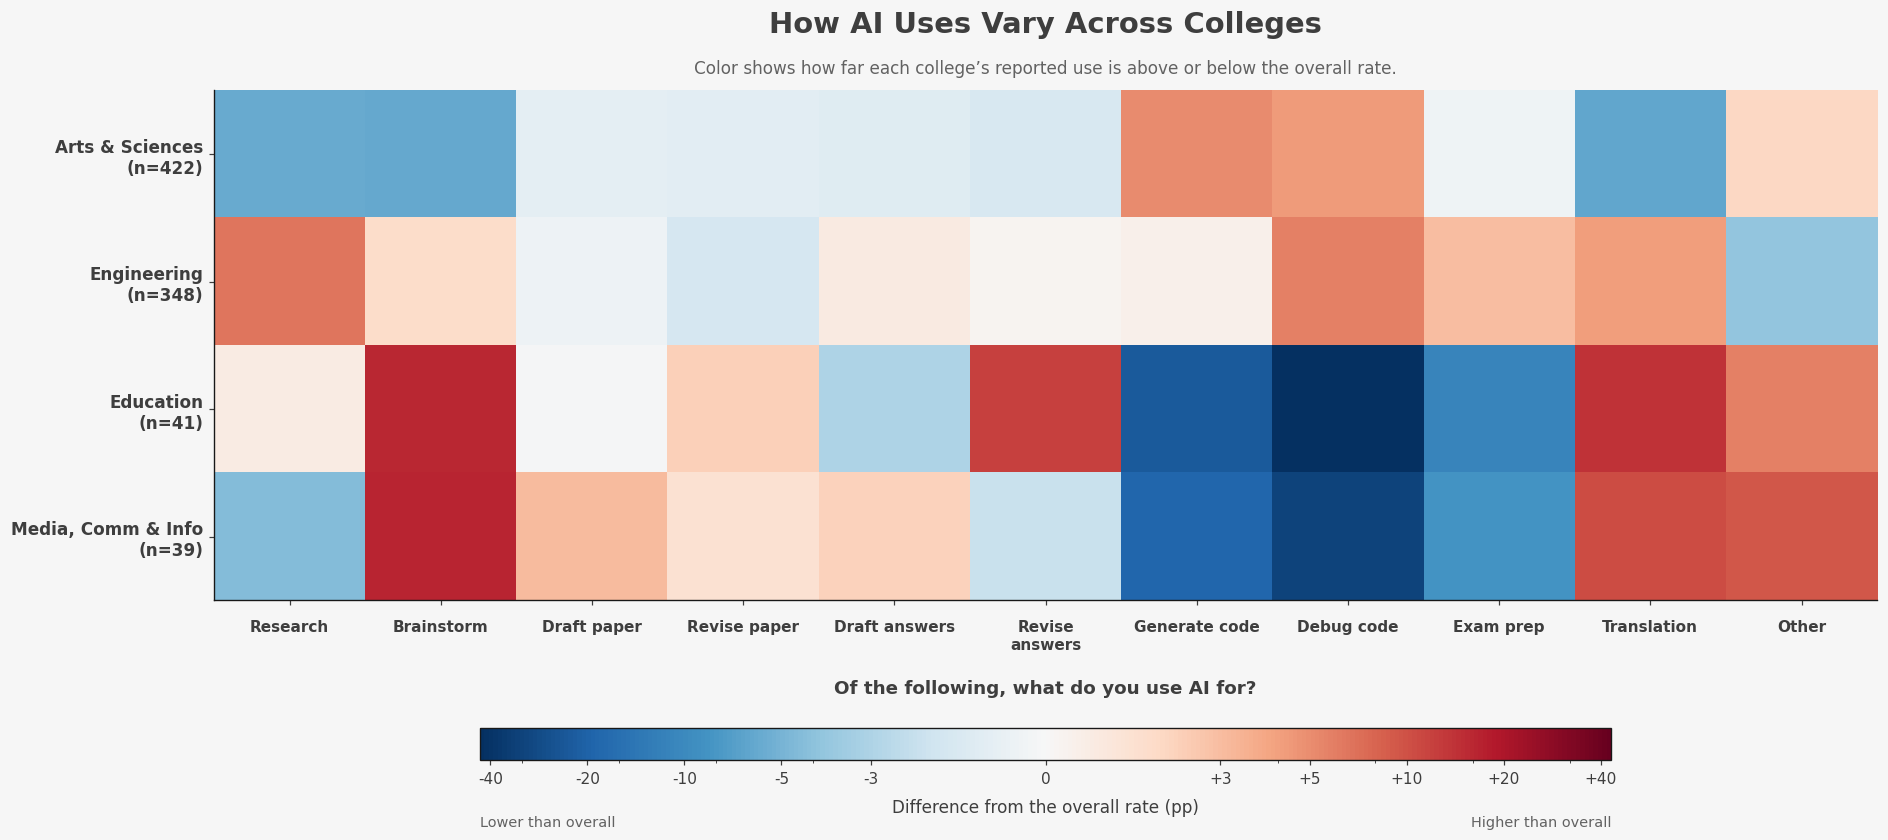

In [269]:
from matplotlib.colors import SymLogNorm

# Compare each college's purpose rate with the overall rate.
purpose_short_order = [PURPOSE_SHORT[code] for code in PURPOSE_COLUMNS]

college_names = (
    college_bases.loc[eligible_colleges]
    .sort_values(ascending=False)
    .index
)
college_order = college_names.to_series().map(COLLEGE_SHORT).tolist()

delta_matrix = (
    college_purpose.pivot(
        index="College",
        columns="PurposeShort",
        values="Delta",
    )
    .reindex(index=college_order, columns=purpose_short_order)
)

# Use the same color range above and below zero.
extent = np.nanmax(
    np.abs(delta_matrix.to_numpy())
)

normalizer = SymLogNorm(
    linthresh=4,
    linscale=1.2,
    vmin=-extent,
    vmax=extent,
    base=2,
)


fig, ax = plt.subplots(figsize=(18, 10))

image = ax.imshow(
    delta_matrix.to_numpy(),
    cmap="RdBu_r",
    norm=normalizer,
    aspect="auto",
    interpolation="nearest",
)

college_labels = [
    f"{COLLEGE_SHORT[name]}\n(n={int(college_bases.loc[name]):,})"
    for name in college_names
]

# Wrap longer labels so they can remain horizontal.
purpose_axis_labels = [
    "\n".join(textwrap.wrap(label, width=13))
    for label in purpose_short_order
]

ax.set_xticks(np.arange(len(purpose_axis_labels)))
ax.set_xticklabels(
    purpose_axis_labels,
    rotation=0,
    ha="center",
    fontsize=10,
    fontweight="semibold",
)

ax.set_yticks(np.arange(len(college_labels)))
ax.set_yticklabels(
    college_labels,
    fontsize=11,
    fontweight="semibold",
)

ax.set_xlabel(
    "Of the following, what do you use AI for?",
    fontsize=12,
    fontweight="semibold",
    labelpad=18,
)

# Draw clear borders around the cells.
ax.grid(False)
ax.set_xticks(
    np.arange(-0.5, len(purpose_axis_labels), 1),
    minor=True,
)
ax.set_yticks(
    np.arange(-0.5, len(college_labels), 1),
    minor=True,
)

ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="x", pad=9)

ax.set_title(
    "How AI Uses Vary Across Colleges",
    fontsize=19,
    fontweight="bold",
    pad=38,
)

ax.text(
    0.5,
    1.025,
    "Color shows how far each college’s reported use is above or below the overall rate.",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="#626262",
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    orientation="horizontal",
    fraction=0.05,
    pad=0.19,
    shrink=0.68,
    aspect=35,
)

tick_candidates = np.array(
    [-40, -20, -10, -5, -3, 0, 3, 5, 10, 20, 40]
)
colorbar_ticks = tick_candidates[
    np.abs(tick_candidates) <= extent
]

colorbar.set_ticks(colorbar_ticks)
colorbar.set_ticklabels(
    [
        "0" if value == 0 else f"{value:+.0f}"
        for value in colorbar_ticks
    ]
)

colorbar.set_label(
    "Difference from the overall rate (percentage points)",
    fontsize=11,
    fontweight="semibold",
    labelpad=8,
)

colorbar.set_label(
    "Difference from the overall rate (pp)",
    fontsize=11,
    fontweight="medium",
    labelpad=8,
)

# Make the meaning of each side explicit.
colorbar.ax.text(
    0,
    -1.7,
    "Lower than overall",
    transform=colorbar.ax.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    color="#626262",
)
colorbar.ax.text(
    1,
    -1.7,
    "Higher than overall",
    transform=colorbar.ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#626262",
)

fig.subplots_adjust(
    left=0.13,
    right=0.97,
    top=0.84,
    bottom=0.23,
)

plt.show()

## 5. Additional checks

These figures show uncertainty for small college samples and check whether the
degree-level code explains much of the difference across colleges. They are useful
background for questions but do not all need to appear in a short presentation.

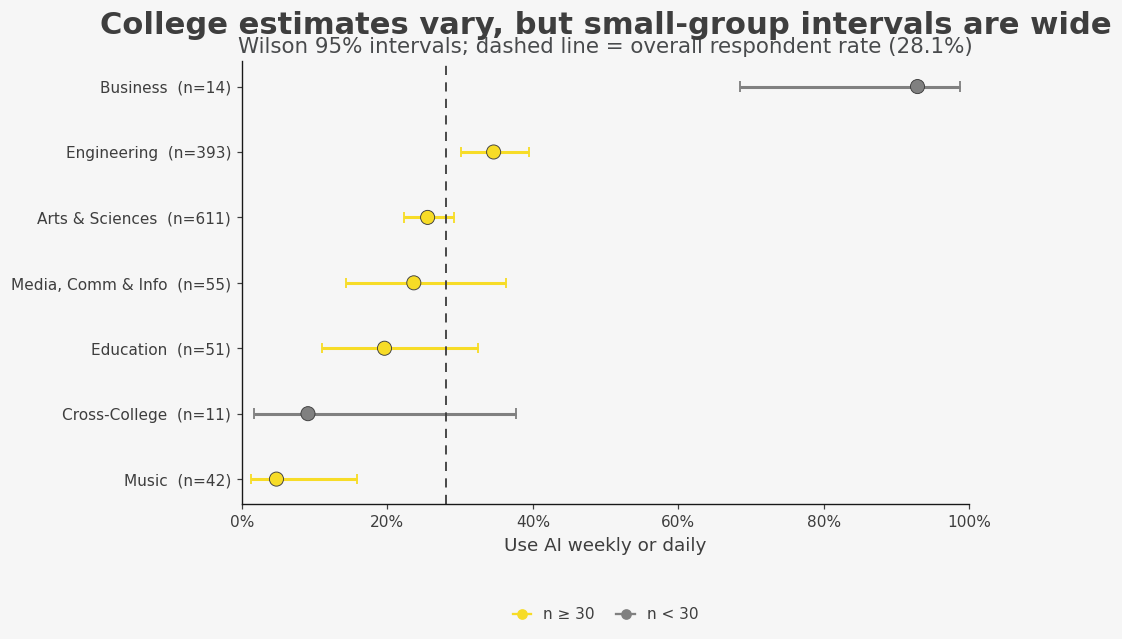

In [251]:
# Show uncertainty and mark colleges with fewer than 30 usable answers.
college_weekly = (
    ai_respondents.groupby(
        ["COLLEGE_CODE1", "COLLEGE_NAME1"],
        observed=True,
    )
    .agg(
        Respondents=(FREQUENCY, "size"),
        Weekly=("weekly_or_more", "sum"),
        Percent=("weekly_or_more", "mean"),
    )
    .reset_index()
)
college_weekly["Percent"] *= 100

# Wilson intervals stay within 0% and 100%, including for small groups.
z = 1.96
p = college_weekly["Weekly"] / college_weekly["Respondents"]
denominator = 1 + z**2 / college_weekly["Respondents"]
center = (p + z**2 / (2 * college_weekly["Respondents"])) / denominator
half_width = (
    z
    * np.sqrt(
        p * (1 - p) / college_weekly["Respondents"]
        + z**2 / (4 * college_weekly["Respondents"] ** 2)
    )
    / denominator
)
college_weekly["Lower"] = 100 * (center - half_width)
college_weekly["Upper"] = 100 * (center + half_width)
college_weekly["College"] = college_weekly["COLLEGE_NAME1"].map(COLLEGE_SHORT)
college_weekly["Sample size"] = np.where(
    college_weekly["Respondents"].ge(30),
    "n ≥ 30",
    "n < 30",
)
college_weekly = college_weekly.sort_values("Percent")
institution_weekly = 100 * ai_respondents["weekly_or_more"].mean()

status_palette = load_palette("Greyjoy")
status_colors = {"n ≥ 30": status_palette[4], "n < 30": status_palette[5]}

fig, ax = plt.subplots(figsize=(10.5, 6.5))
y = np.arange(len(college_weekly))
colors = college_weekly["Sample size"].map(status_colors)
for y_value, (_, row), color in zip(
    y,
    college_weekly.iterrows(),
    colors,
):
    ax.hlines(
        y_value,
        row["Lower"],
        row["Upper"],
        color=color,
        linewidth=2,
    )
    ax.vlines(
        [row["Lower"], row["Upper"]],
        y_value - 0.08,
        y_value + 0.08,
        color=color,
        linewidth=1.2,
    )
ax.scatter(
    college_weekly["Percent"],
    y,
    c=colors,
    s=85,
    edgecolor="#3E3E3E",
    linewidth=0.6,
    zorder=3,
)
ax.axvline(
    institution_weekly,
    color="#3E3E3E",
    linestyle=(0, (5, 4)),
    linewidth=1.2,
)
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{college}  (n={n:,})"
        for college, n in zip(
            college_weekly["College"],
            college_weekly["Respondents"],
        )
    ]
)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.set_xlabel("Use AI weekly or daily")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color=status_colors[label],
        linestyle="-",
        label=label,
    )
    for label in ["n ≥ 30", "n < 30"]
]
legend_below(ax, handles, ["n ≥ 30", "n < 30"], ncol=2, y=-0.2)
add_title(
    ax,
    "College estimates vary, but small-group intervals are wide",
    f"Wilson 95% intervals; dashed line = overall respondent rate ({institution_weekly:.1f}%)",
)
plt.subplots_adjust(left=0.27, bottom=0.2, top=0.82)
plt.show()

College,Respondents,Reported rate,Level-adjusted rate,Difference
Business,14,92.9%,92.5%,-0.4 pp
Engineering,393,34.6%,34.6%,-0.0 pp
Arts & Sciences,611,25.5%,25.3%,-0.3 pp
"Media, Comm & Info",55,23.6%,23.7%,+0.0 pp
Education,51,19.6%,21.2%,+1.6 pp
Cross-College,11,9.1%,11.0%,+1.9 pp
Music,42,4.8%,4.9%,+0.2 pp


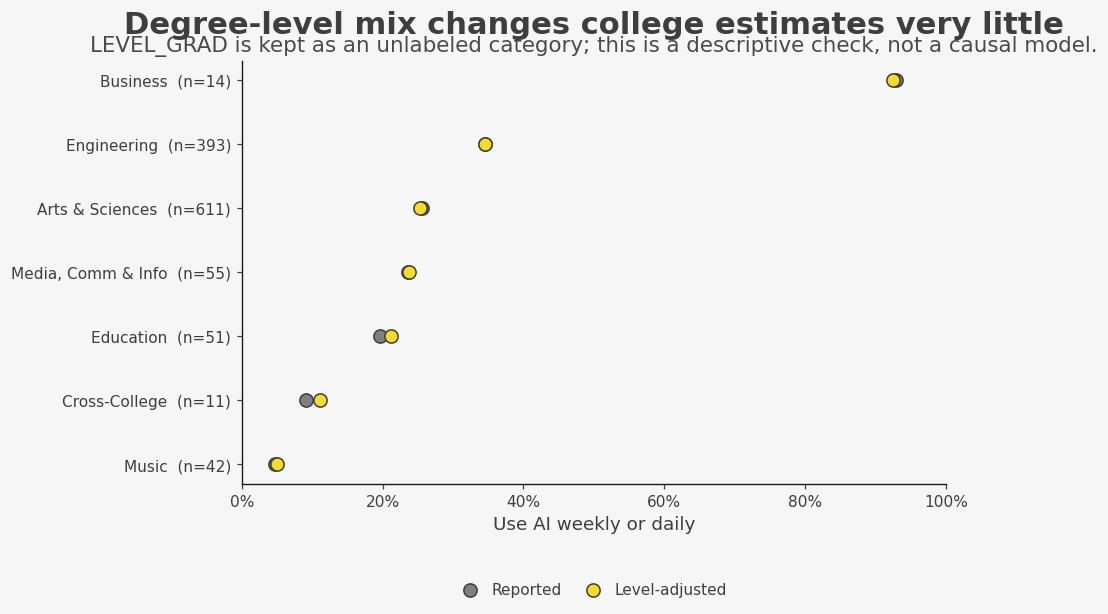

In [252]:
# Check how much college rates change after holding the degree-level mix constant.
model_data = ai_respondents.dropna(
    subset=["COLLEGE_CODE1", "COLLEGE_NAME1", "LEVEL_GRAD"]
).copy()
model_data["weekly"] = model_data["weekly_or_more"].astype(int)
model_data["level_code"] = model_data["LEVEL_GRAD"].astype(int).astype(str)

design = pd.get_dummies(
    model_data[["COLLEGE_CODE1", "level_code"]].astype(str),
    drop_first=False,
    dtype=float,
)
with warnings.catch_warnings():
    # Hide a scikit-learn warning caused by the no-penalty model setting.
    warnings.filterwarnings(
        "ignore",
        message="Setting penalty=None will ignore.*",
        category=UserWarning,
    )
    weekly_model = LogisticRegression(
        C=np.inf,
        l1_ratio=0,
        solver="lbfgs",
        max_iter=2000,
    ).fit(design, model_data["weekly"])

adjusted_rows = []
for college_code, college_name in (
    model_data[["COLLEGE_CODE1", "COLLEGE_NAME1"]]
    .drop_duplicates()
    .sort_values("COLLEGE_CODE1")
    .itertuples(index=False)
):
    scenario = model_data[["COLLEGE_CODE1", "level_code"]].astype(str).copy()
    scenario["COLLEGE_CODE1"] = college_code
    scenario_design = pd.get_dummies(
        scenario,
        drop_first=False,
        dtype=float,
    ).reindex(columns=design.columns, fill_value=0)
    college_observed = model_data.loc[
        model_data["COLLEGE_CODE1"].eq(college_code)
    ]
    adjusted_rows.append(
        {
            "College": COLLEGE_SHORT[college_name],
            "Respondents": len(college_observed),
            "Reported rate": 100 * college_observed["weekly"].mean(),
            "Level-adjusted rate": 100
            * weekly_model.predict_proba(scenario_design)[:, 1].mean(),
        }
    )

college_adjustment = pd.DataFrame(adjusted_rows)
college_adjustment["Difference"] = (
    college_adjustment["Level-adjusted rate"]
    - college_adjustment["Reported rate"]
)
college_adjustment = college_adjustment.sort_values("Reported rate")

display(
    style_table(
        college_adjustment.sort_values(
            "Reported rate",
            ascending=False,
        ),
        (
            "Degree-level mix check; largest change = "
            f"{college_adjustment['Difference'].abs().max():.1f} percentage points"
        ),
        {
            "Respondents": "{:,.0f}",
            "Reported rate": "{:.1f}%",
            "Level-adjusted rate": "{:.1f}%",
            "Difference": "{:+.1f} pp",
        },
        shade_columns=[
            "Respondents",
            "Reported rate",
            "Level-adjusted rate",
        ],
    )
)

adjustment_palette = load_palette("Greyjoy")
fig, ax = plt.subplots(figsize=(10, 6.2))
y = np.arange(len(college_adjustment))
ax.hlines(
    y,
    college_adjustment["Reported rate"],
    college_adjustment["Level-adjusted rate"],
    color=adjustment_palette[5],
    linewidth=2,
)
ax.scatter(
    college_adjustment["Reported rate"],
    y,
    color=adjustment_palette[5],
    edgecolor="#3E3E3E",
    s=75,
    label="Reported",
    zorder=3,
)
ax.scatter(
    college_adjustment["Level-adjusted rate"],
    y,
    color=adjustment_palette[4],
    edgecolor="#3E3E3E",
    s=75,
    label="Level-adjusted",
    zorder=3,
)
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{college}  (n={n:,})"
        for college, n in zip(
            college_adjustment["College"],
            college_adjustment["Respondents"],
        )
    ]
)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.set_xlabel("Use AI weekly or daily")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=2, y=-0.2)
add_title(
    ax,
    "Degree-level mix changes college estimates very little",
    "LEVEL_GRAD is kept as an unlabeled category; this is a descriptive check, not a causal model.",
)
plt.subplots_adjust(left=0.26, bottom=0.2, top=0.82)
plt.show()

In [253]:
# Keep fields as codes when the file does not supply their labels.
level_audit = (
    survey.groupby("LEVEL_GRAD", observed=True)
    .agg(
        Respondents=("respondent_id", "size"),
        Programs=("PROGRAM_CODE1", "nunique"),
        Earliest_entry_year=("ENTRY_YEAR", "min"),
        Latest_entry_year=("ENTRY_YEAR", "max"),
    )
    .reset_index()
    .rename(
        columns={
            "LEVEL_GRAD": "Degree-level code",
            "Earliest_entry_year": "Earliest entry year",
            "Latest_entry_year": "Latest entry year",
        }
    )
)

entry_years = pd.to_numeric(survey["ENTRY_YEAR"], errors="coerce")
entry_note = pd.DataFrame(
    {
        "Field": [
            "ENTRY_YEAR / ENTRY_TERM",
            "LEVEL_GRAD",
            "Gender / race",
        ],
        "What is in the file": [
            (
                f"Entry years span {entry_years.min():.0f}–{entry_years.max():.0f}; "
                f"terms include {', '.join(sorted(survey['ENTRY_TERM'].dropna().unique()))}"
            ),
            "Observed codes: "
            + ", ".join(
                map(
                    str,
                    sorted(
                        survey["LEVEL_GRAD"]
                        .dropna()
                        .astype(int)
                        .unique()
                    ),
                )
            ),
            "No gender or race field appears in the supplied 289 columns",
        ],
        "How it is used": [
            "Treated as entry information, not the year the survey was taken",
            "Kept as a category because degree labels were not supplied",
            "No gender or race groups are inferred",
        ],
    }
)

display(
    style_table(
        level_audit,
        "Degree-level codes in the file",
        {
            "Degree-level code": "{:.0f}",
            "Respondents": "{:,.0f}",
            "Programs": "{:,.0f}",
            "Earliest entry year": "{:.0f}",
            "Latest entry year": "{:.0f}",
        },
        shade_columns=[
            "Respondents",
            "Programs",
            "Earliest entry year",
            "Latest entry year",
        ],
    )
)
display(style_table(entry_note, "Fields without supplied labels"))

Degree-level code,Respondents,Programs,Earliest entry year,Latest entry year
1,327,45,2006,2025
3,"1,054",56,2005,2025
4,6,1,2021,2024


Field,What is in the file,How it is used
ENTRY_YEAR / ENTRY_TERM,"Entry years span 2005–2025; terms include Fall, Spring, Summer","Treated as entry information, not the year the survey was taken"
LEVEL_GRAD,"Observed codes: 1, 3, 4",Kept as a category because degree labels were not supplied
Gender / race,No gender or race field appears in the supplied 289 columns,No gender or race groups are inferred


## 6. Suggested presentation order

1. **Adoption:** AI use is common, but students use it at very different rates.
2. **Purposes:** Research, coding, and brainstorming are the leading reported uses.
3. **Guidance gap:** Students report more understanding than faculty or program guidance.
4. **College variation:** Purpose profiles differ across colleges with adequate samples.
5. **Action:** Pair university-wide principles with examples that fit each discipline.

### Points to mention

- This is one self-reported, unweighted survey.
- The file has no population counts, invitation records, gender, or race, so respondent
  characteristics cannot show whether the sample represents all graduate students.
- The number of usable answers differs across questions.
- Small college estimates are uncertain. Very small program groups should not be shown
  without a clear minimum-sample rule.
- Labels for `LEVEL_GRAD` and details about survey weights were not supplied.
- The results describe patterns among respondents; they do not show that AI use caused
  any outcome.

### Next analysis

After the presentation figures are final, examine satisfaction outcomes using a small,
clearly chosen set of AI-use and program variables. Check results with held-out data or
resampling, and present them as associations rather than effects.